1. Open `pipeline/Subsetting.py`
2. Find the right category dictionary (or create a new one)
3. Add an entry: `"BRFSS_CODE": "your_clean_name"`
4. If you made a new dict, add it to the `RENAME_MAP` loop
5. Re-run: `uv run python pipeline/Subsetting.py`
6. Update this README with the new variable

The BRFSS codebook is in `data/raw/` or online at the CDC site.

This Exploratory Data Analysis (EDA) was built according to the following structure. 

Step 1. Understand the data shape and structure. 

Step 2. Check missing values 

Step 3. Summary statistics 

Step 4. Features selection 

Step 5. Categorize the data (demographics, lifestyle, health outcomes, physical)

Step 6. Missing values in each category

Step 7. Visualization

 a) Distribution of data gathered in the survey 

	- Demographics
	- Access to Care (insurance, etc.)
	- Health outcomes (current health status)
	- Lifestyle 
	- Socieconomic (urban, metropolitan area)
	- Physical indexes (bmi)

 b) Comparison all categories vs. Diabetes status 

 c) Comparison all categories vs. Heart Disease status 

In [ ]:
import pandas as pd

path = "/Users/davidcolin/Documents/Hertie/DSA/scream/project-scream/data/subsets/brfss2024_subset.parquet"
df = pd.read_parquet(path, engine='fastparquet')

print(df.head())

Step 1. Understand the data shape and structure. 

Our data frame has 78 columns and 457670 rows
All the entries in our data set is float64


In [2]:
df.shape

(457670, 78)

In [ ]:
df.dtypes.unique()

In [4]:
print(df.tail(5))

        state_fips  primary_sampling_unit  sex_raw  general_health  \
457665        78.0           2.024001e+09      1.0             7.0   
457666        78.0           2.024001e+09      1.0             4.0   
457667        78.0           2.024001e+09      1.0             3.0   
457668        78.0           2.024001e+09      1.0             1.0   
457669        78.0           2.024001e+09      1.0             3.0   

        days_poor_physical_health  days_poor_mental_health  \
457665                       77.0                      2.0   
457666                        5.0                      1.0   
457667                       88.0                     88.0   
457668                       88.0                     88.0   
457669                       30.0                     88.0   

        days_poor_health_overall  insurance_type  has_personal_doctor  \
457665                      77.0             3.0                  1.0   
457666                      88.0            88.0            

In [5]:
df.columns.tolist()

['state_fips',
 'primary_sampling_unit',
 'sex_raw',
 'general_health',
 'days_poor_physical_health',
 'days_poor_mental_health',
 'days_poor_health_overall',
 'insurance_type',
 'has_personal_doctor',
 'cant_afford_doctor',
 'time_since_checkup',
 'exercised_past_30d',
 'last_dentist_visit',
 'had_heart_attack',
 'has_heart_disease',
 'had_stroke',
 'had_asthma',
 'has_skin_cancer',
 'has_other_cancer',
 'has_copd',
 'has_depression',
 'has_kidney_disease',
 'has_arthritis',
 'has_diabetes',
 'diabetes_age_diagnosed',
 'marital_status',
 'education_raw',
 'own_or_rent',
 'is_veteran',
 'employment_status',
 'num_children',
 'income_raw',
 'difficulty_hearing',
 'difficulty_seeing',
 'difficulty_concentrating',
 'difficulty_walking',
 'difficulty_dressing',
 'difficulty_errands',
 'smoked_100_cigs_ever',
 'alcohol_days_past_30d',
 'had_flu_shot_12mo',
 'last_blood_sugar_test',
 'has_prediabetes',
 'life_satisfaction',
 'emotional_support_freq',
 'loneliness_freq',
 'lost_employment',
 

Step 2. Check missing values 

We found that the most relevant missing values are related to age group but this is already separated in our further analysis and graphs. And the remaining features are not relevant for our diabetes and heart disease EDA/prediction. 

In [6]:
print(df.isnull().sum())


state_fips                   0
primary_sampling_unit        0
sex_raw                      0
general_health               5
days_poor_physical_health    5
                            ..
income_level                 0
smoking_status               0
any_alcohol_past_30d         0
is_binge_drinker             0
is_heavy_drinker             0
Length: 78, dtype: int64


In [7]:
print(df.isnull().sum()/len(df)*100)


state_fips                   0.000000
primary_sampling_unit        0.000000
sex_raw                      0.000000
general_health               0.001092
days_poor_physical_health    0.001092
                               ...   
income_level                 0.000000
smoking_status               0.000000
any_alcohol_past_30d         0.000000
is_binge_drinker             0.000000
is_heavy_drinker             0.000000
Length: 78, dtype: float64


In [8]:
missing_percent = df.isnull().sum()/len(df)*100
missing_percent = missing_percent[missing_percent > 0]
missing_percent_sorted = missing_percent.sort_values(ascending=False)
print(missing_percent_sorted)

diabetes_age_diagnosed       85.620862
last_blood_sugar_test        65.223196
has_prediabetes              65.216204
neighborhood_safety          55.996897
lacks_transportation         55.921516
cant_pay_utilities           55.861647
cant_pay_bills               55.815762
food_insecurity              55.764197
receives_food_stamps         55.697555
lost_employment              55.648611
loneliness_freq              55.600979
emotional_support_freq       55.543951
life_satisfaction            55.477964
days_poor_health_overall     41.388118
bmi_category                  9.403500
bmi_x100                      9.403500
had_flu_shot_12mo             9.068761
alcohol_days_past_30d         8.569712
weight_kg                     7.951581
height_inches                 6.956541
smoked_100_cigs_ever          6.305854
difficulty_errands            4.486420
difficulty_dressing           4.251753
difficulty_walking            4.079795
difficulty_concentrating      3.810824
difficulty_seeing        

Step 3. Summary statistics 

In [9]:
print(df.describe())

          state_fips  primary_sampling_unit        sex_raw  general_health  \
count  457670.000000           4.576700e+05  457670.000000   457665.000000   
mean       30.823537           2.024007e+09       1.524795        2.659362   
std        15.939364           7.488291e+03       0.499385        1.081163   
min         1.000000           2.024000e+09       1.000000        1.000000   
25%        18.000000           2.024002e+09       1.000000        2.000000   
50%        31.000000           2.024005e+09       2.000000        3.000000   
75%        44.000000           2.024008e+09       2.000000        3.000000   
max        78.000000           2.024044e+09       2.000000        9.000000   

       days_poor_physical_health  days_poor_mental_health  \
count              457665.000000            457667.000000   
mean                   57.918113                57.728739   
std                    37.872634                38.072038   
min                     1.000000                 1.00

In [10]:
print(df["race_ethnicity"].unique())
print(df["race_ethnicity_5lvl"].unique())


[1. 7. 2. 4. 8. 9. 6. 3. 5.]
[1. 4. 2. 3. 5. 9.]


Step 4. Features selection 

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


columns_to_drop = [
    'state_fips', 'age_imputed', 'age_group_6', 'primary_sampling_unit', 'stratification_var', 'survey_weight',
    'age_group_65', 'race_ethnicity_imputed', 'race_ethnicity_5lvl', 'last_dentist_visit'
]

df = df.drop(columns=columns_to_drop, errors='ignore') 


# Demographics
demographics = [
    'sex', 'age_group_5yr', 'race_ethnicity',
    'marital_status', 'education_level', 'income_level', 'own_or_rent', 'employment_status', 'is_veteran'
]

# Health outcomes / comorbidities
health_outcomes = [
    'general_health', 'days_poor_physical_health', 'days_poor_mental_health',
    'days_poor_health_overall', 'had_heart_attack', 'has_heart_disease',
    'had_stroke', 'had_asthma', 'has_skin_cancer', 'has_other_cancer',
    'has_copd', 'has_depression', 'has_kidney_disease', 'has_arthritis',
    'has_diabetes', 'diabetes_age_diagnosed', 'has_prediabetes'
]

# Lifestyle / behaviors
lifestyle = [
    'any_physical_activity', 'exercised_past_30d', 'smoking_status',
    'smoked_100_cigs_ever', 'any_alcohol_past_30d', 'alcohol_days_past_30d',
    'is_binge_drinker', 'is_heavy_drinker'
]

# Access to healthcare
access_to_care = [
    'insurance_type', 'has_insurance', 'has_insurance_18_64', 
    'has_personal_doctor', 'cant_afford_doctor', 'time_since_checkup',
    'last_blood_sugar_test'
]

# Socioeconomic / psychosocial (optional)
socioeconomic = [
    'life_satisfaction', 'emotional_support_freq', 'loneliness_freq', 
    'lost_employment', 'receives_food_stamps', 'food_insecurity',
    'cant_pay_bills', 'cant_pay_utilities', 'lacks_transportation',
    'neighborhood_safety', 'metro_status', 'urban_rural'
]

# Physical measurements
physical = ['height_inches', 'weight_kg', 'bmi_x100', 'bmi_category']


Step 5. Categorize the data (demographics, lifestyle, health outcomes, physical)

In [12]:
# Demographics
df_demographics = df[demographics]

# Health outcomes / comorbidities
df_health_outcomes = df[health_outcomes]
    
# Lifestyle / behaviors
df_lifestyle = df[lifestyle]

# Access to healthcare
df_access_to_care = df[access_to_care] 

# Socioeconomic / psychosocial
df_socioeconomic = df[socioeconomic]

# Physical measurements
df_physical = df[physical]

Step 6. Missing values in each category

In [13]:
missing_percent_demographics = df_demographics.isnull().sum()/len(df)*100
missing_percent_demographics = missing_percent_demographics[missing_percent_demographics > 0]
missing_percent_demographics_sorted = missing_percent_demographics.sort_values(ascending=False)
print(missing_percent_demographics_sorted)

employment_status    0.721699
is_veteran           0.269845
marital_status       0.001966
own_or_rent          0.001748
dtype: float64


In [14]:
df_demographics.dropna()


,sex,age_group_5yr,race_ethnicity,marital_status,education_level,income_level,own_or_rent,employment_status,is_veteran
0,2.0,12.0,1.0,3.0,2.0,9.0,1.0,7.0,2.0
1,1.0,13.0,1.0,1.0,4.0,7.0,1.0,7.0,1.0
2,1.0,8.0,1.0,6.0,3.0,9.0,1.0,1.0,1.0
3,1.0,13.0,1.0,1.0,4.0,4.0,1.0,7.0,2.0
4,1.0,6.0,1.0,5.0,3.0,2.0,1.0,8.0,2.0
...,...,...,...,...,...,...,...,...,...
457664,1.0,10.0,2.0,3.0,2.0,1.0,1.0,8.0,2.0
457666,1.0,10.0,2.0,5.0,1.0,4.0,2.0,1.0,2.0
457667,1.0,12.0,2.0,5.0,4.0,5.0,1.0,7.0,2.0
457668,1.0,6.0,1.0,1.0,3.0,6.0,1.0,2.0,2.0


In [15]:
missing_percent_health_outcomes = df_health_outcomes.isnull().sum()/len(df)*100
missing_percent_health_outcomes = missing_percent_health_outcomes[missing_percent_health_outcomes > 0]
missing_percent_health_outcomes_sorted = missing_percent_health_outcomes.sort_values(ascending=False)
print(missing_percent_health_outcomes_sorted)

diabetes_age_diagnosed       85.620862
has_prediabetes              65.216204
days_poor_health_overall     41.388118
has_copd                      0.001529
has_kidney_disease            0.001311
has_skin_cancer               0.001311
days_poor_physical_health     0.001092
has_other_cancer              0.001092
has_depression                0.001092
has_arthritis                 0.001092
general_health                0.001092
has_diabetes                  0.000874
had_stroke                    0.000655
had_asthma                    0.000655
has_heart_disease             0.000655
days_poor_mental_health       0.000655
had_heart_attack              0.000437
dtype: float64


In [16]:
df_health_outcomes = df_health_outcomes.drop(columns=['diabetes_age_diagnosed', 'has_prediabetes', 'days_poor_health_overall'], errors='ignore')
print(df_health_outcomes.columns)

Index(['general_health', 'days_poor_physical_health',
       'days_poor_mental_health', 'had_heart_attack', 'has_heart_disease',
       'had_stroke', 'had_asthma', 'has_skin_cancer', 'has_other_cancer',
       'has_copd', 'has_depression', 'has_kidney_disease', 'has_arthritis',
       'has_diabetes'],
      dtype='str')


In [17]:
df_health_outcomes.shape

(457670, 14)

In [18]:
df_health_outcomes.dropna()


,general_health,days_poor_physical_health,days_poor_mental_health,had_heart_attack,has_heart_disease,had_stroke,had_asthma,has_skin_cancer,has_other_cancer,has_copd,has_depression,has_kidney_disease,has_arthritis,has_diabetes
0,3.0,2.0,88.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,3.0
1,1.0,88.0,88.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0
2,2.0,30.0,88.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0
3,1.0,88.0,88.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,3.0
4,3.0,88.0,88.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457665,7.0,77.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0
457666,4.0,5.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7.0,2.0,2.0,3.0
457667,3.0,88.0,88.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0
457668,1.0,88.0,88.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0


In [19]:
missing_percent_lifestyle = df_lifestyle.isnull().sum()/len(df)*100
missing_percent_lifestyle = missing_percent_lifestyle[missing_percent_lifestyle > 0]
missing_percent_lifestyle_sorted = missing_percent_lifestyle.sort_values(ascending=False)
print(missing_percent_lifestyle_sorted)

alcohol_days_past_30d    8.569712
smoked_100_cigs_ever     6.305854
exercised_past_30d       0.000655
dtype: float64


In [20]:
df_lifestyle.dropna()

,any_physical_activity,exercised_past_30d,smoking_status,smoked_100_cigs_ever,any_alcohol_past_30d,alcohol_days_past_30d,is_binge_drinker,is_heavy_drinker
0,1.0,1.0,4.0,2.0,2.0,888.0,1.0,1.0
1,1.0,1.0,3.0,1.0,2.0,888.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,230.0,2.0,1.0
3,1.0,1.0,4.0,2.0,2.0,888.0,1.0,1.0
4,2.0,2.0,4.0,2.0,2.0,888.0,1.0,1.0
...,...,...,...,...,...,...,...,...
457663,1.0,1.0,4.0,2.0,2.0,888.0,1.0,1.0
457664,2.0,2.0,4.0,2.0,2.0,888.0,1.0,1.0
457666,2.0,2.0,1.0,1.0,1.0,230.0,9.0,2.0
457667,2.0,2.0,4.0,2.0,1.0,202.0,1.0,1.0


In [21]:
missing_percent_access_to_care = df_access_to_care.isnull().sum()/len(df)*100
missing_percent_access_to_care = missing_percent_access_to_care[missing_percent_access_to_care > 0]
missing_percent_access_to_care_sorted = missing_percent_access_to_care.sort_values(ascending=False)
print(missing_percent_access_to_care_sorted)

last_blood_sugar_test    65.223196
cant_afford_doctor        0.001311
insurance_type            0.000655
has_personal_doctor       0.000655
time_since_checkup        0.000437
dtype: float64


In [22]:
df_access_to_care = df_access_to_care.drop("last_blood_sugar_test", axis=1)
print(df_access_to_care.columns)

Index(['insurance_type', 'has_insurance', 'has_insurance_18_64',
       'has_personal_doctor', 'cant_afford_doctor', 'time_since_checkup'],
      dtype='str')


In [23]:
df_access_to_care.dropna()

,insurance_type,has_insurance,has_insurance_18_64,has_personal_doctor,cant_afford_doctor,time_since_checkup
0,3.0,1.0,9.0,2.0,2.0,1.0
1,3.0,1.0,9.0,1.0,2.0,1.0
2,1.0,1.0,1.0,3.0,1.0,4.0
3,3.0,1.0,9.0,1.0,2.0,1.0
4,5.0,1.0,1.0,1.0,2.0,1.0
...,...,...,...,...,...,...
457665,3.0,1.0,9.0,1.0,1.0,3.0
457666,88.0,2.0,9.0,3.0,2.0,2.0
457667,1.0,1.0,9.0,2.0,2.0,3.0
457668,2.0,1.0,1.0,2.0,2.0,2.0


In [24]:
missing_percent_socioeconomic = df_socioeconomic.isnull().sum()/len(df)*100
missing_percent_socioeconomic = missing_percent_socioeconomic[missing_percent_socioeconomic > 0]
missing_percent_socioeconomic_sorted = missing_percent_socioeconomic.sort_values(ascending=False)
print(missing_percent_socioeconomic_sorted)

neighborhood_safety       55.996897
lacks_transportation      55.921516
cant_pay_utilities        55.861647
cant_pay_bills            55.815762
food_insecurity           55.764197
receives_food_stamps      55.697555
lost_employment           55.648611
loneliness_freq           55.600979
emotional_support_freq    55.543951
life_satisfaction         55.477964
metro_status               3.195097
urban_rural                3.195097
dtype: float64


In [25]:
df_socioeconomic = df_socioeconomic[["metro_status", "urban_rural"]]

In [26]:
df_socioeconomic.dropna()  

,metro_status,urban_rural
0,1.0,1.0
1,1.0,1.0
2,2.0,1.0
3,2.0,1.0
4,1.0,1.0
...,...,...
450348,2.0,1.0
450349,2.0,1.0
450350,1.0,1.0
450351,2.0,1.0


In [27]:
missing_percent_physical = df_physical.isnull().sum()/len(df)*100
missing_percent_physical = missing_percent_physical[missing_percent_physical > 0]
missing_percent_physical_sorted = missing_percent_physical.sort_values(ascending=False)
print(missing_percent_physical_sorted)

bmi_x100         9.403500
bmi_category     9.403500
weight_kg        7.951581
height_inches    6.956541
dtype: float64


In [28]:
df_physical.dropna()

,height_inches,weight_kg,bmi_x100,bmi_category
0,64.0,5942.0,2249.0,2.0
1,70.0,8165.0,2583.0,3.0
2,78.0,8845.0,2253.0,2.0
3,68.0,7484.0,2509.0,3.0
4,68.0,5897.0,1977.0,2.0
...,...,...,...,...
457664,66.0,8391.0,2986.0,3.0
457666,66.0,5806.0,2066.0,2.0
457667,69.0,7484.0,2437.0,2.0
457668,72.0,8165.0,2441.0,2.0


Step 7. Visualization

In [29]:
print(df_demographics.columns)
print(df_access_to_care.columns)
print(df_health_outcomes.columns)
print(df_lifestyle.columns)
print(df_socioeconomic.columns)
print(df_physical.columns)

Index(['sex', 'age_group_5yr', 'race_ethnicity', 'marital_status',
       'education_level', 'income_level', 'own_or_rent', 'employment_status',
       'is_veteran'],
      dtype='str')
Index(['insurance_type', 'has_insurance', 'has_insurance_18_64',
       'has_personal_doctor', 'cant_afford_doctor', 'time_since_checkup'],
      dtype='str')
Index(['general_health', 'days_poor_physical_health',
       'days_poor_mental_health', 'had_heart_attack', 'has_heart_disease',
       'had_stroke', 'had_asthma', 'has_skin_cancer', 'has_other_cancer',
       'has_copd', 'has_depression', 'has_kidney_disease', 'has_arthritis',
       'has_diabetes'],
      dtype='str')
Index(['any_physical_activity', 'exercised_past_30d', 'smoking_status',
       'smoked_100_cigs_ever', 'any_alcohol_past_30d', 'alcohol_days_past_30d',
       'is_binge_drinker', 'is_heavy_drinker'],
      dtype='str')
Index(['metro_status', 'urban_rural'], dtype='str')
Index(['height_inches', 'weight_kg', 'bmi_x100', 'bmi_category

Index(['sex', 'age_group_5yr', 'race_ethnicity', 'marital_status',
       'education_level', 'income_level'],
      dtype='str')
Index(['has_insurance'],
      dtype='str')
Index(['general_health',
       'days_poor_mental_health', 'has_heart_disease','has_other_cancer',
       'has_copd', 'has_depression', 'has_kidney_disease', 'has_arthritis',
       'has_diabetes'],
      dtype='str')
Index(['any_physical_activity', 'exercised_past_30d', 'smoking_status',
       'is_binge_drinker', 'is_heavy_drinker'],
      dtype='str')
Index(['metro_status', 'urban_rural'], dtype='str')
Index(['bmi_category'], dtype='str')

In [ ]:

LABEL_MAPS = {
    #  Demographics 
    "sex": {1: "Male", 2: "Female"},
    "age_group_5yr": {
        1: "18–24", 2: "25–29", 3: "30–34", 4: "35–39", 5: "40–44",
        6: "45–49", 7: "50–54", 8: "55–59", 9: "60–64", 10: "65–69",
        11: "70–74", 12: "75–79", 13: "80+", 14: "Unknown",
    },
    "race_ethnicity": {
        1: "White (non-Hispanic)", 2: "Black (non-Hispanic)",
        3: "Am. Indian / Alaska Native", 4: "Asian (non-Hispanic)",
        5: "Native Hawaiian / Pacific Isl.", 6: "Other (non-Hispanic)",
        7: "Multiracial (non-Hispanic)", 8: "Hispanic", 9: "Unknown",
    },
    "marital_status": {
        1: "Married", 2: "Divorced", 3: "Widowed",
        4: "Separated", 5: "Never married", 6: "Unmarried couple", 9: "Unknown",
    },
    "education_level": {
        1: "Never attended school", 2: "Elementary",
        3: "Some high school", 4: "High school grad",
        5: "Some college", 6: "College graduate", 9: "Unknown",
    },
    "income_level": {
        1: "<$10k", 2: "$10k–$15k", 3: "$15k–$20k", 4: "$20k–$25k",
        5: "$25k–$35k", 6: "$35k–$50k", 7: "$50k–$75k", 8: "$75k+",
        77: "Unknown", 99: "Unknown",
    },
    "own_or_rent": {1: "Own", 2: "Rent", 3: "Other arrangement", 7: "Unknown", 9: "Unknown"},
    "employment_status": {
        1: "Employed (wages)", 2: "Self-employed", 3: "Out of work (1+ yr)",
        4: "Out of work (<1 yr)", 5: "Homemaker", 6: "Student",
        7: "Retired", 8: "Unable to work", 9: "Unknown",
    },
    "is_veteran": {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    #  Access to care 
    "has_insurance":       {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_insurance_18_64": {1: "Yes", 2: "No", 9: "Unknown"},
    "has_personal_doctor": {1: "Yes, only one", 2: "Yes, more than one", 3: "No", 7: "Unknown", 9: "Unknown"},
    "cant_afford_doctor":  {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "time_since_checkup": {
        1: "Within past year", 2: "1–2 years ago",
        3: "2–5 years ago", 4: "5+ years ago", 8: "Never", 7: "Unknown", 9: "Unknown",
    },
    "insurance_type": {
        1: "Employer-based", 2: "Individual purchase", 3: "Medicare",
        4: "Medigap", 5: "Medicaid", 6: "Children's Health Insurance",
        7: "Military / VA", 8: "Indian Health Service",
        9: "State-sponsored", 10: "Other govt program",
        88: "No coverage", 77: "Unknown", 99: "Unknown",
    },
    #  Health outcomes 
    "general_health": {
        1: "Excellent", 2: "Very good", 3: "Good",
        4: "Fair", 5: "Poor", 7: "Unknown", 9: "Unknown",
    },
    "has_diabetes": {
        1: "Yes", 2: "Yes (pregnancy)", 3: "No",
        4: "Pre-diabetes / borderline", 7: "Unknown", 9: "Unknown",
    },
    "has_heart_disease":  {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "had_heart_attack":   {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "had_stroke":         {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "had_asthma":         {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_skin_cancer":    {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_other_cancer":   {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_copd":           {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_depression":     {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_kidney_disease": {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "has_arthritis":      {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    #  Lifestyle 
    "any_physical_activity": {1: "Yes", 2: "No", 9: "Unknown"},
    "exercised_past_30d":    {1: "Yes", 2: "No", 9: "Unknown"},
    "smoking_status": {
        1: "Current (daily)", 2: "Current (some days)",
        3: "Former smoker", 4: "Never smoked", 9: "Unknown",
    },
    "smoked_100_cigs_ever": {1: "Yes", 2: "No", 7: "Unknown", 9: "Unknown"},
    "any_alcohol_past_30d": {1: "Yes", 2: "No", 9: "Unknown"},
    "is_binge_drinker":     {1: "Yes", 2: "No", 9: "Unknown"},
    "is_heavy_drinker":     {1: "Yes", 2: "No", 9: "Unknown"},
    #  Socioeconomic 
    "metro_status": {1: "Metro", 2: "Non-metro"},
    "urban_rural":  {1: "Urban centre", 2: "Suburban", 3: "Rural", 4: "Unknown"},
    #  Physical 
    "bmi_category": {
        1: "Underweight (<18.5)", 2: "Normal (18.5–25)",
        3: "Overweight (25–30)",  4: "Obese (30+)",
    },
}

def apply_labels(series, col):
    """Map raw BRFSS numeric codes to descriptive strings."""
    mapping = LABEL_MAPS.get(col, {})
    if mapping:
        return series.map(mapping).fillna(series.astype(str))
    return series.astype(str)


a) Distribution of data gathered in the survey 

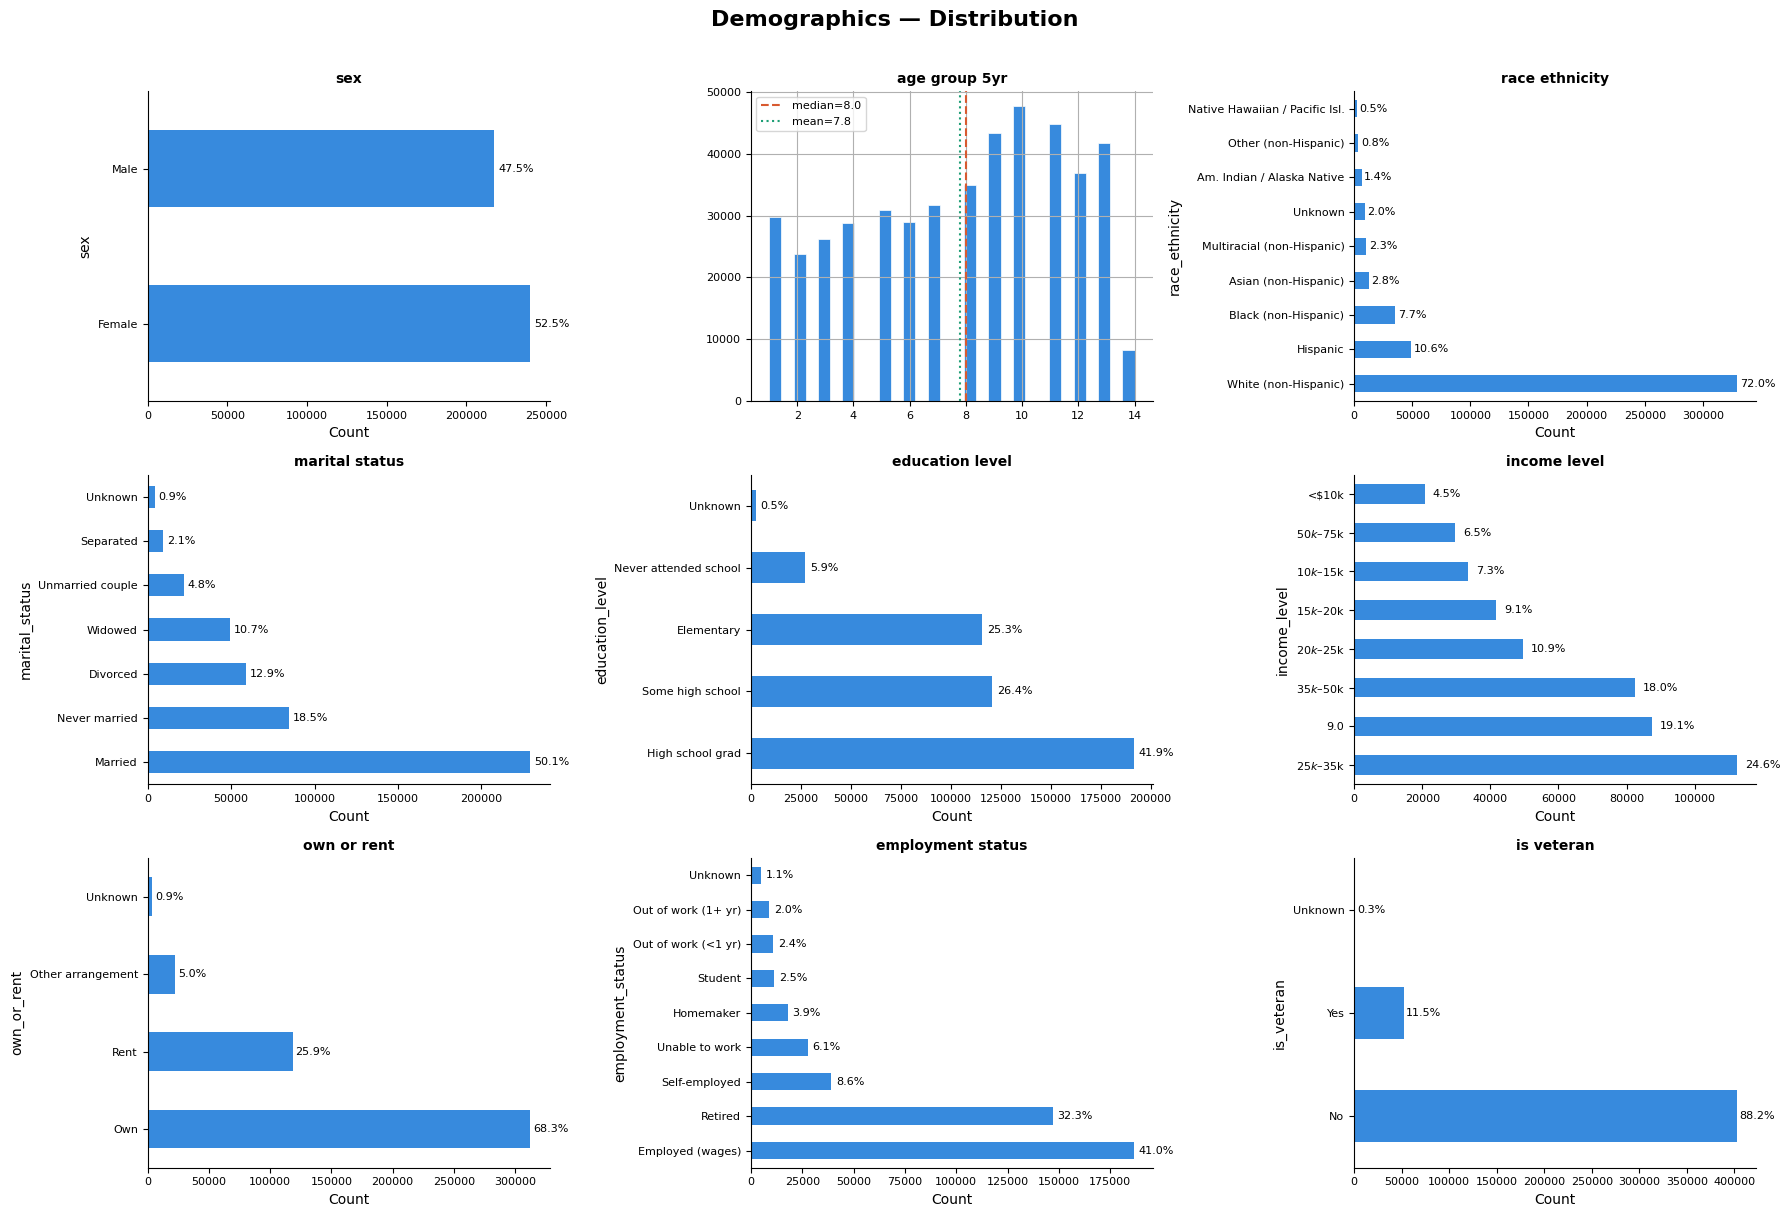

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

cols = df_demographics.columns.tolist()
ncols = 3
nrows = -(-len(cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle("Demographics — Distribution", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    series = df_demographics[col].dropna()

    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        series.hist(bins=30, ax=ax, color="#378ADD", edgecolor="white", linewidth=0.5)
        ax.axvline(series.median(), color="#D85A30", linewidth=1.5, linestyle="--", label=f"median={series.median():.1f}")
        ax.axvline(series.mean(),   color="#1D9E75", linewidth=1.5, linestyle=":",  label=f"mean={series.mean():.1f}")
        ax.legend(fontsize=8)
    else:
        series_labeled = apply_labels(series, col)
        vc = series_labeled.value_counts()
        vc.plot(kind="barh", ax=ax, color="#378ADD")
        ax.set_xlabel("Count")
        for bar in ax.patches:
            pct = bar.get_width() / len(series) * 100
            ax.text(bar.get_width() + len(series) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", va="center", fontsize=8)

    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


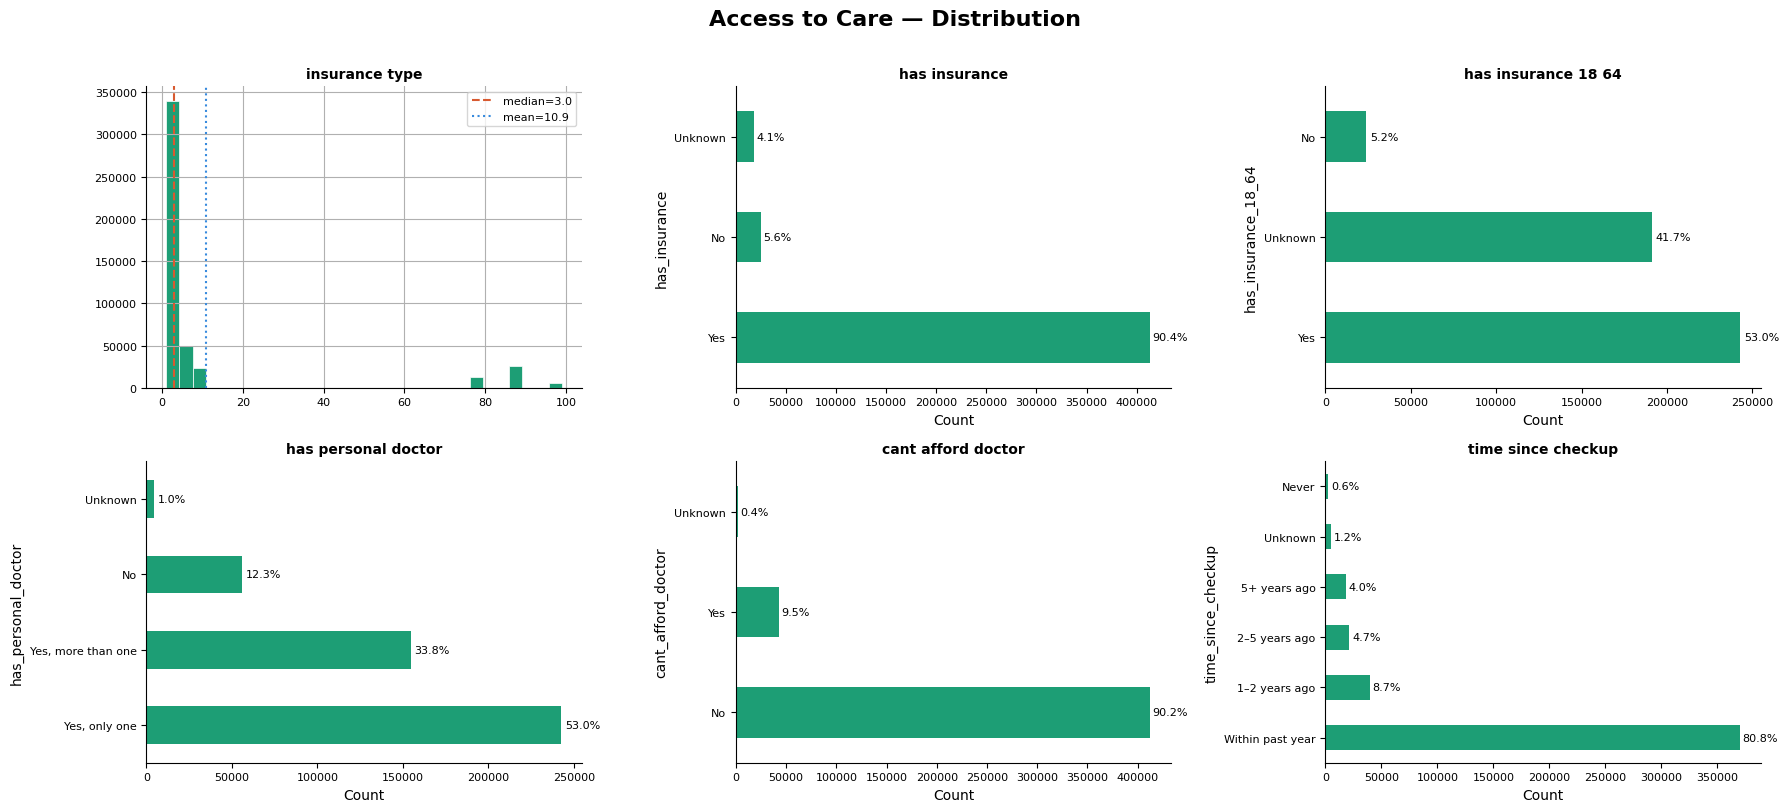

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

cols = df_access_to_care.columns.tolist()
ncols = 3
nrows = -(-len(cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle("Access to Care — Distribution", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    series = df_access_to_care[col].dropna()

    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        series.hist(bins=30, ax=ax, color="#1D9E75", edgecolor="white", linewidth=0.5)
        ax.axvline(series.median(), color="#D85A30", linewidth=1.5, linestyle="--", label=f"median={series.median():.1f}")
        ax.axvline(series.mean(),   color="#378ADD", linewidth=1.5, linestyle=":",  label=f"mean={series.mean():.1f}")
        ax.legend(fontsize=8)
    else:
        series_labeled = apply_labels(series, col)
        vc = series_labeled.value_counts()
        vc.plot(kind="barh", ax=ax, color="#1D9E75")
        ax.set_xlabel("Count")
        for bar in ax.patches:
            pct = bar.get_width() / len(series) * 100
            ax.text(bar.get_width() + len(series) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", va="center", fontsize=8)

    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("distribution_access_to_care.png", dpi=150, bbox_inches="tight")
plt.show()


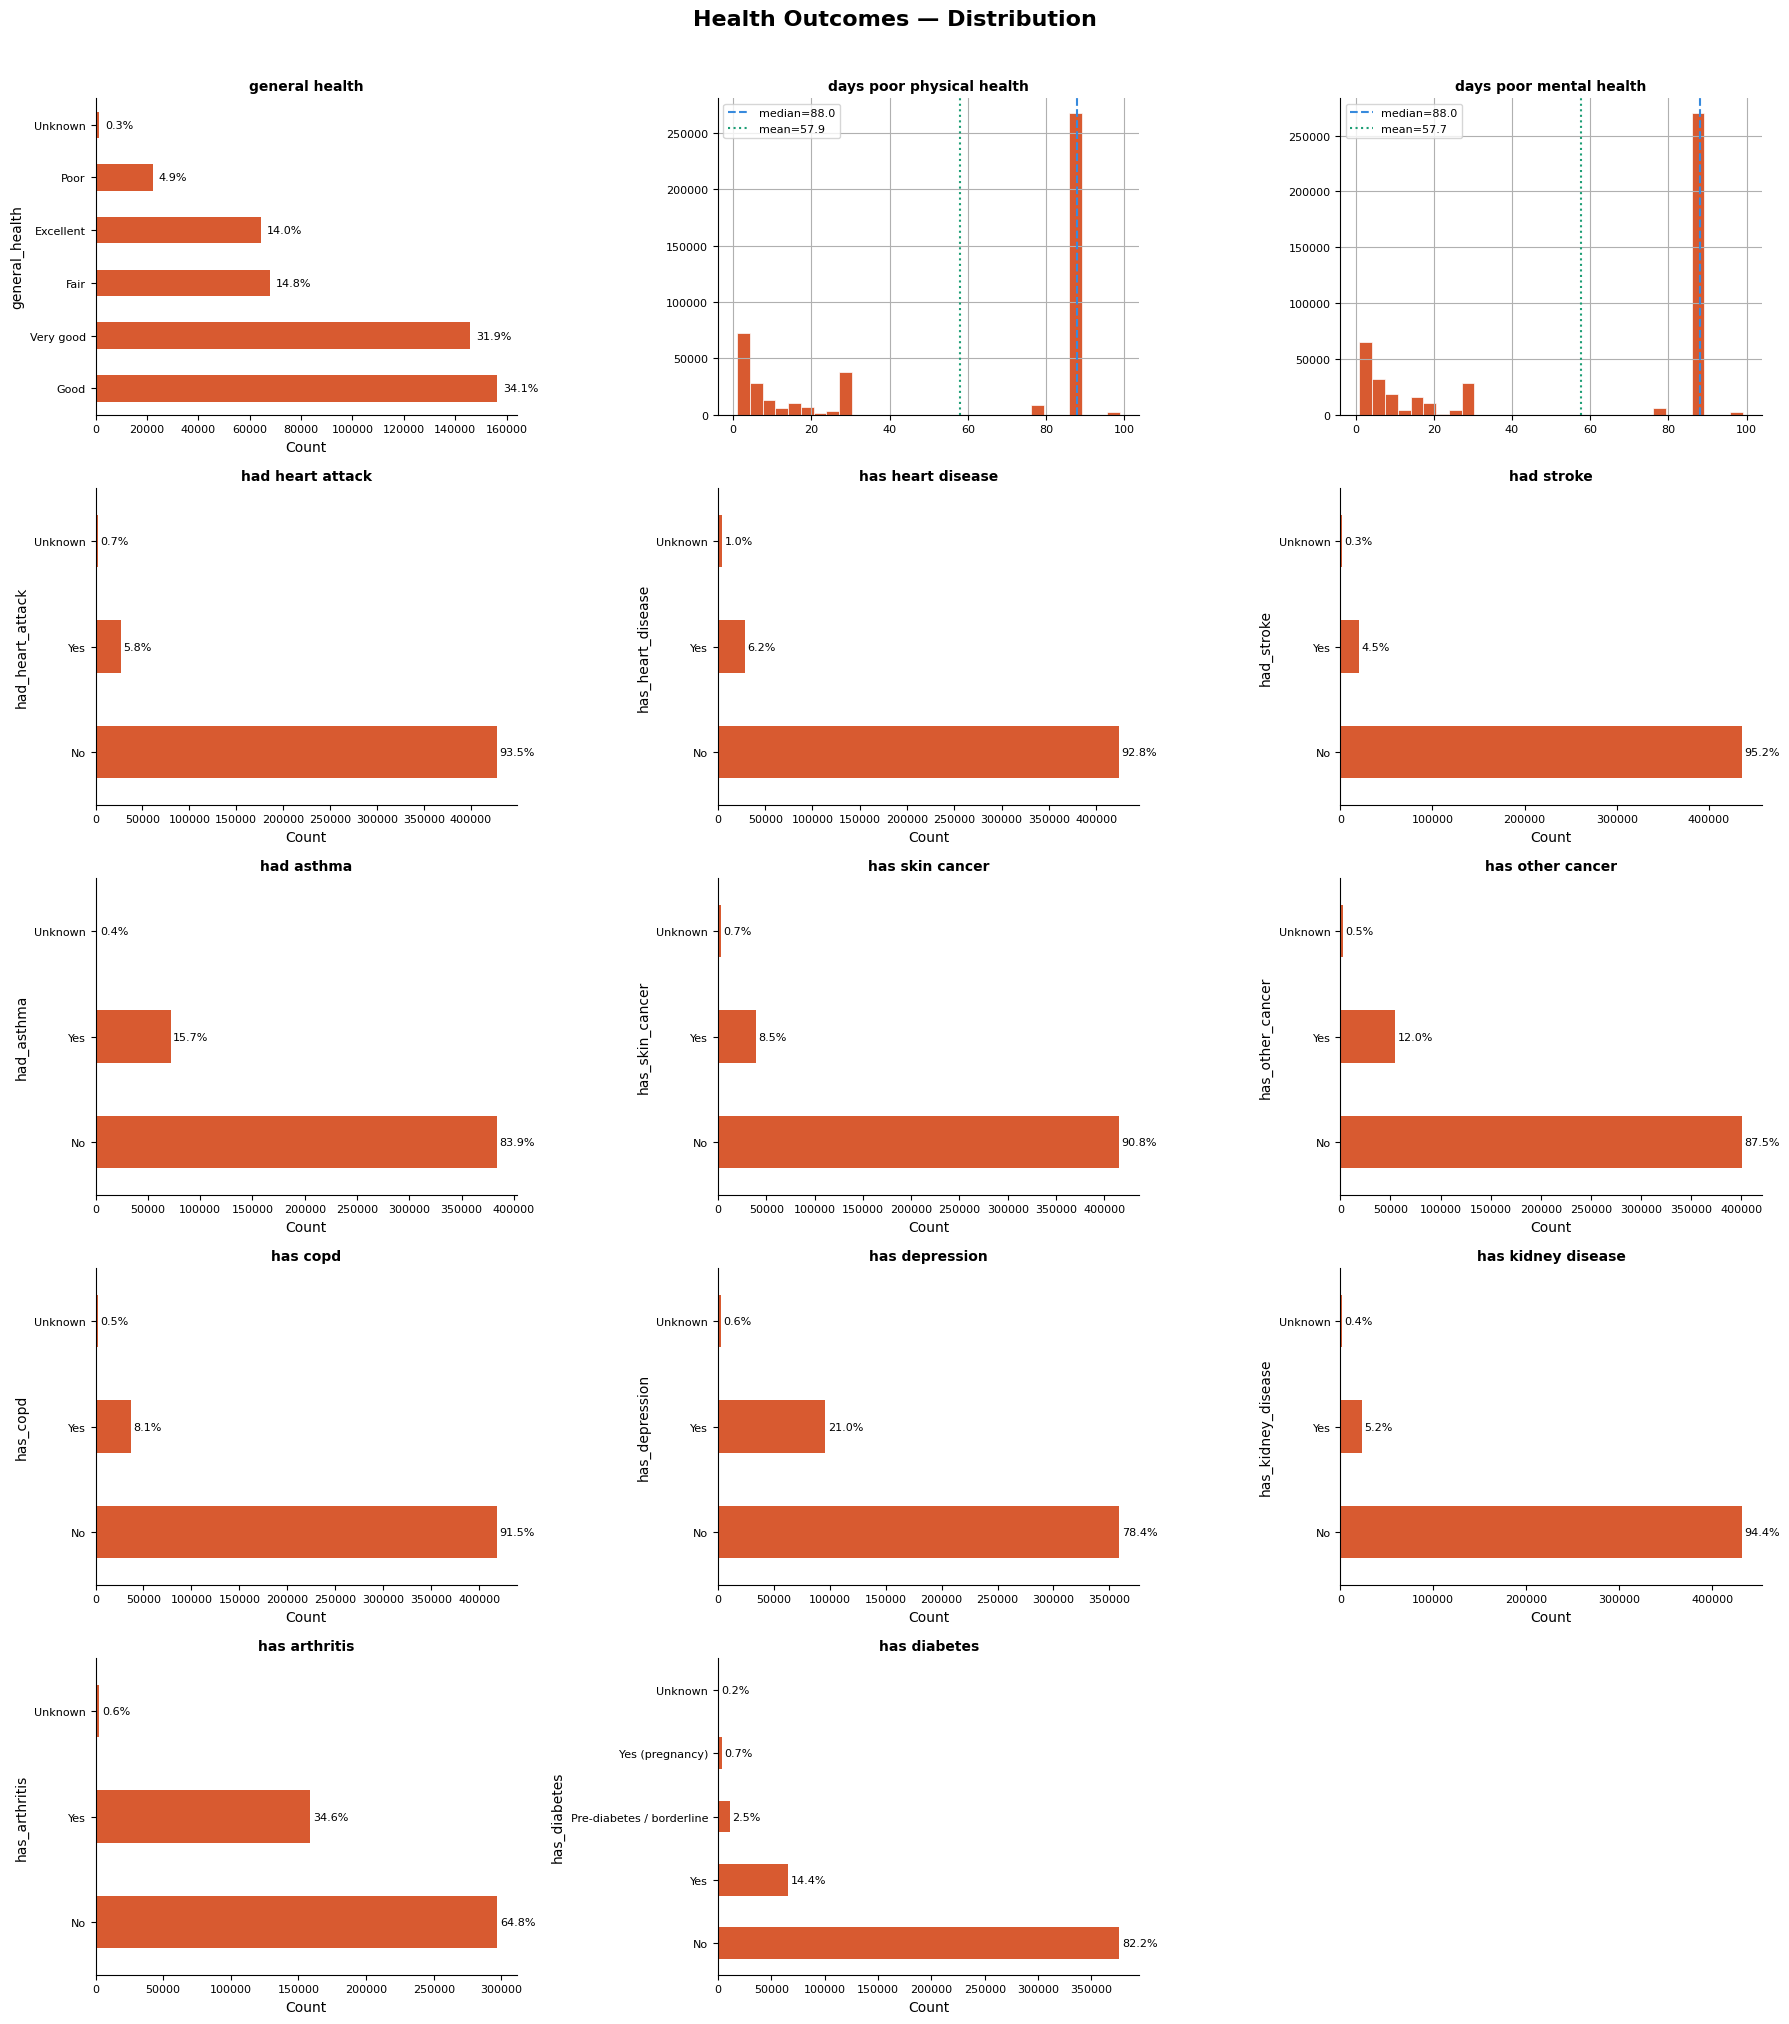

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

cols = df_health_outcomes.columns.tolist()
ncols = 3
nrows = -(-len(cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle("Health Outcomes — Distribution", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    series = df_health_outcomes[col].dropna()

    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        series.hist(bins=30, ax=ax, color="#D85A30", edgecolor="white", linewidth=0.5)
        ax.axvline(series.median(), color="#378ADD", linewidth=1.5, linestyle="--", label=f"median={series.median():.1f}")
        ax.axvline(series.mean(),   color="#1D9E75", linewidth=1.5, linestyle=":",  label=f"mean={series.mean():.1f}")
        ax.legend(fontsize=8)
    else:
        series_labeled = apply_labels(series, col)
        vc = series_labeled.value_counts()
        vc.plot(kind="barh", ax=ax, color="#D85A30")
        ax.set_xlabel("Count")
        for bar in ax.patches:
            pct = bar.get_width() / len(series) * 100
            ax.text(bar.get_width() + len(series) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", va="center", fontsize=8)

    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("distribution_health_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()


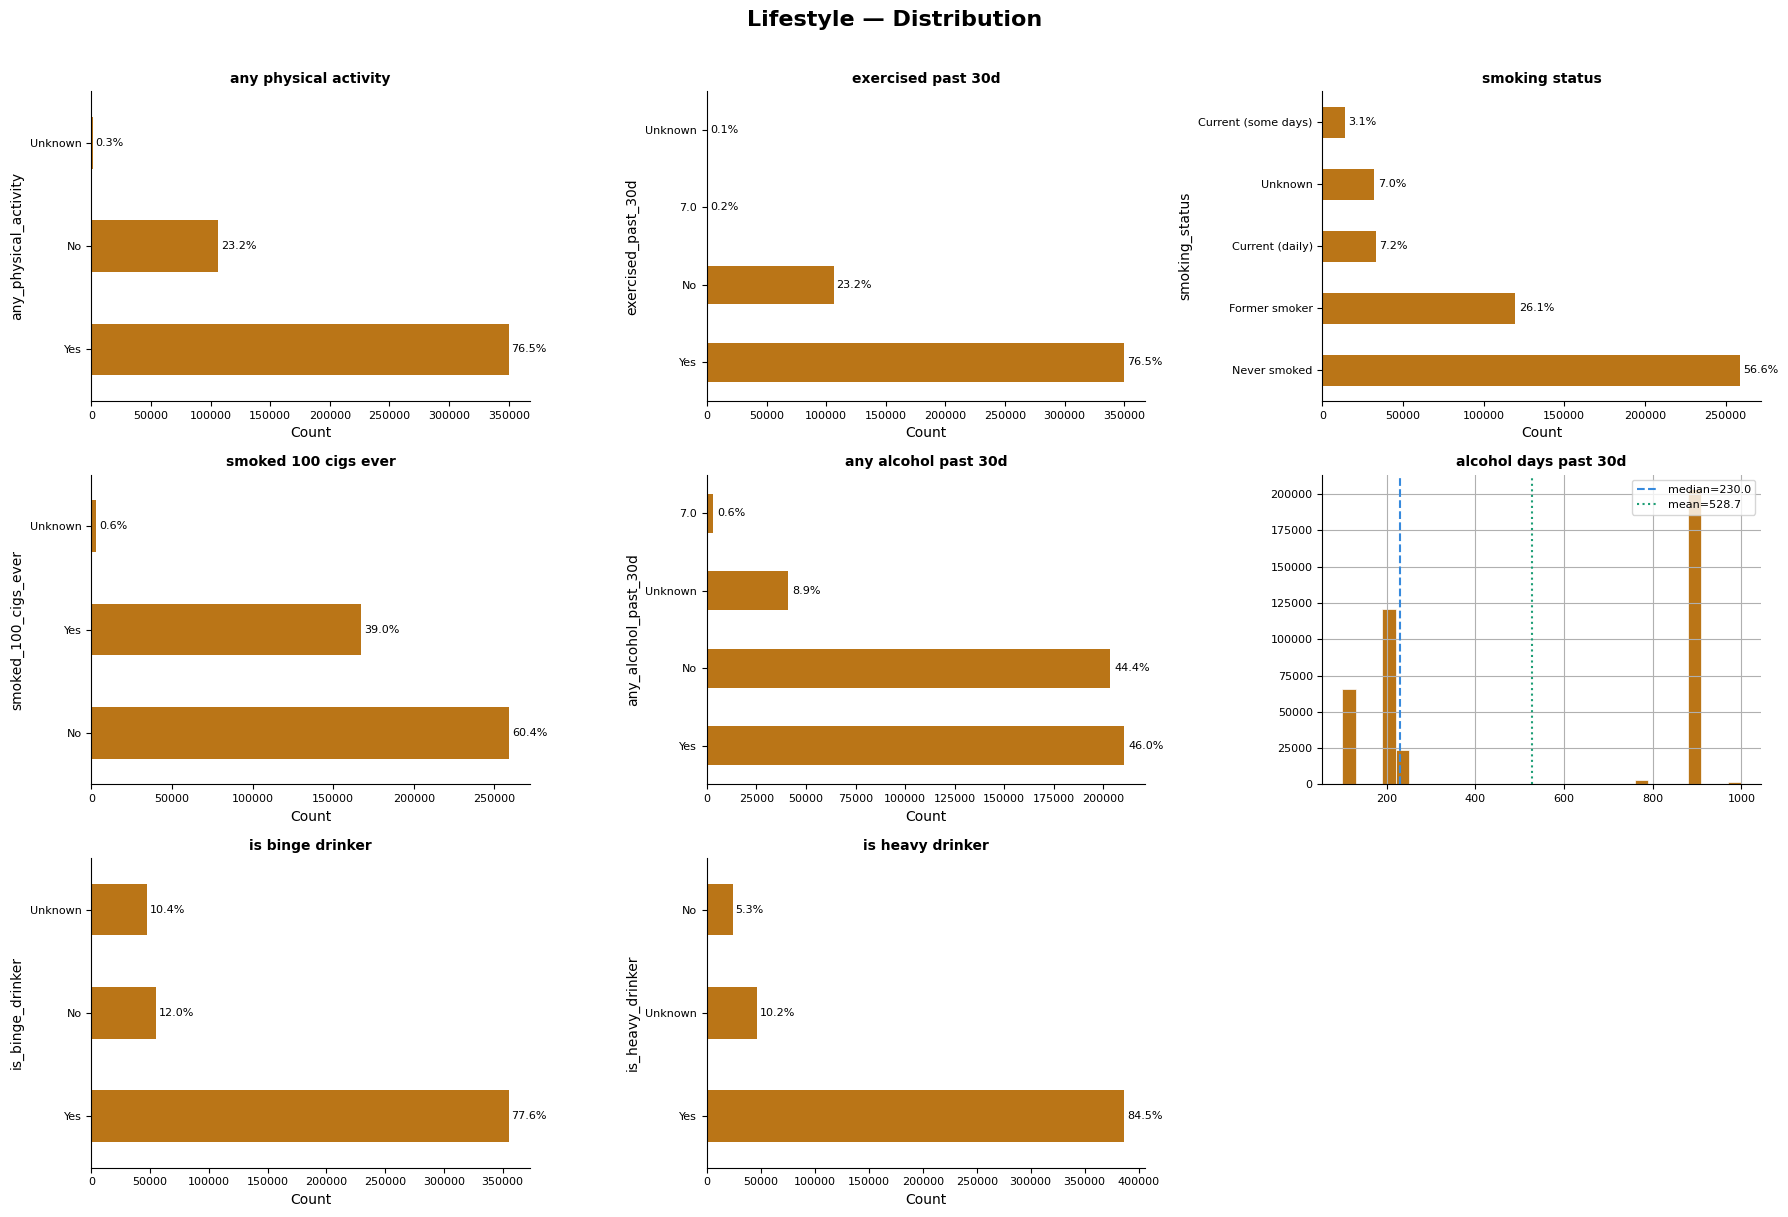

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

cols = df_lifestyle.columns.tolist()
ncols = 3
nrows = -(-len(cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle("Lifestyle — Distribution", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    series = df_lifestyle[col].dropna()

    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        series.hist(bins=30, ax=ax, color="#BA7517", edgecolor="white", linewidth=0.5)
        ax.axvline(series.median(), color="#378ADD", linewidth=1.5, linestyle="--", label=f"median={series.median():.1f}")
        ax.axvline(series.mean(),   color="#1D9E75", linewidth=1.5, linestyle=":",  label=f"mean={series.mean():.1f}")
        ax.legend(fontsize=8)
    else:
        series_labeled = apply_labels(series, col)
        vc = series_labeled.value_counts()
        vc.plot(kind="barh", ax=ax, color="#BA7517")
        ax.set_xlabel("Count")
        for bar in ax.patches:
            pct = bar.get_width() / len(series) * 100
            ax.text(bar.get_width() + len(series) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", va="center", fontsize=8)

    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("distribution_lifestyle.png", dpi=150, bbox_inches="tight")
plt.show()


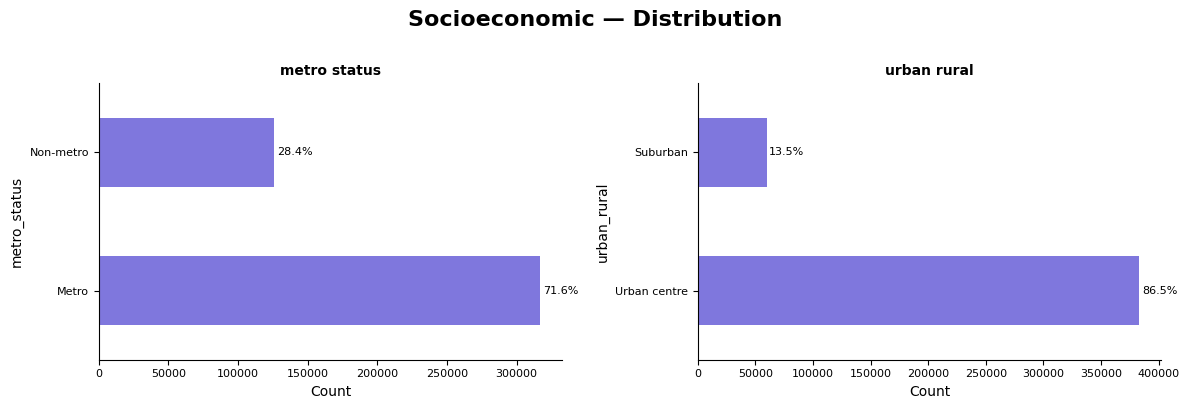

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

cols = df_socioeconomic.columns.tolist()
ncols = 2
nrows = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4))
fig.suptitle("Socioeconomic — Distribution", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    series = df_socioeconomic[col].dropna()

    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        series.hist(bins=30, ax=ax, color="#7F77DD", edgecolor="white", linewidth=0.5)
        ax.axvline(series.median(), color="#D85A30", linewidth=1.5, linestyle="--", label=f"median={series.median():.1f}")
        ax.axvline(series.mean(),   color="#1D9E75", linewidth=1.5, linestyle=":",  label=f"mean={series.mean():.1f}")
        ax.legend(fontsize=8)
    else:
        series_labeled = apply_labels(series, col)
        vc = series_labeled.value_counts()
        vc.plot(kind="barh", ax=ax, color="#7F77DD")
        ax.set_xlabel("Count")
        for bar in ax.patches:
            pct = bar.get_width() / len(series) * 100
            ax.text(bar.get_width() + len(series) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", va="center", fontsize=8)

    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("distribution_socioeconomic.png", dpi=150, bbox_inches="tight")
plt.show()


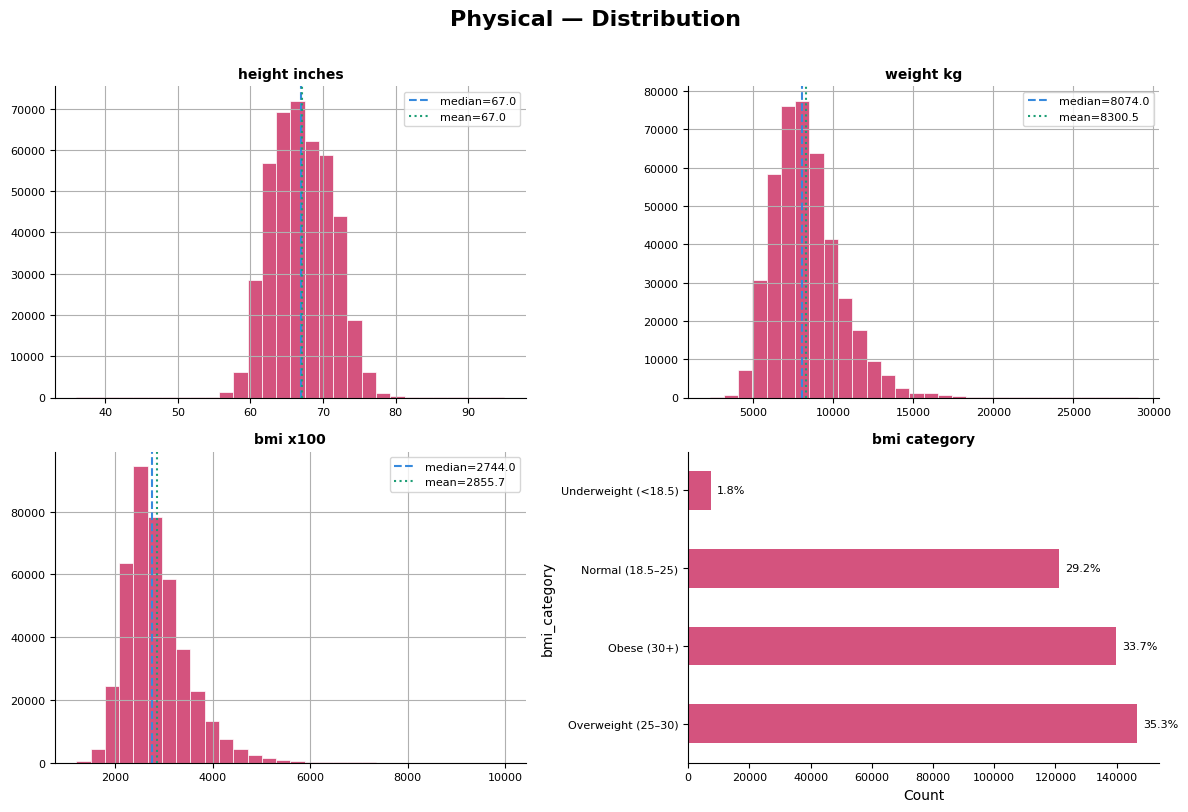

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

cols = df_physical.columns.tolist()
ncols = 2
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
fig.suptitle("Physical — Distribution", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    series = df_physical[col].dropna()

    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        series.hist(bins=30, ax=ax, color="#D4537E", edgecolor="white", linewidth=0.5)
        ax.axvline(series.median(), color="#378ADD", linewidth=1.5, linestyle="--", label=f"median={series.median():.1f}")
        ax.axvline(series.mean(),   color="#1D9E75", linewidth=1.5, linestyle=":",  label=f"mean={series.mean():.1f}")
        ax.legend(fontsize=8)
    else:
        series_labeled = apply_labels(series, col)
        vc = series_labeled.value_counts()
        vc.plot(kind="barh", ax=ax, color="#D4537E")
        ax.set_xlabel("Count")
        for bar in ax.patches:
            pct = bar.get_width() / len(series) * 100
            ax.text(bar.get_width() + len(series) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%", va="center", fontsize=8)

    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("distribution_physical.png", dpi=150, bbox_inches="tight")
plt.show()


b) Comparison all categories vs. Diabetes status 

In [37]:

df_health_outcomes = df_health_outcomes.dropna(subset=['has_diabetes'])
df_health_outcomes['has_diabetes'].unique()


array([3., 1., 4., 2., 9., 7.])

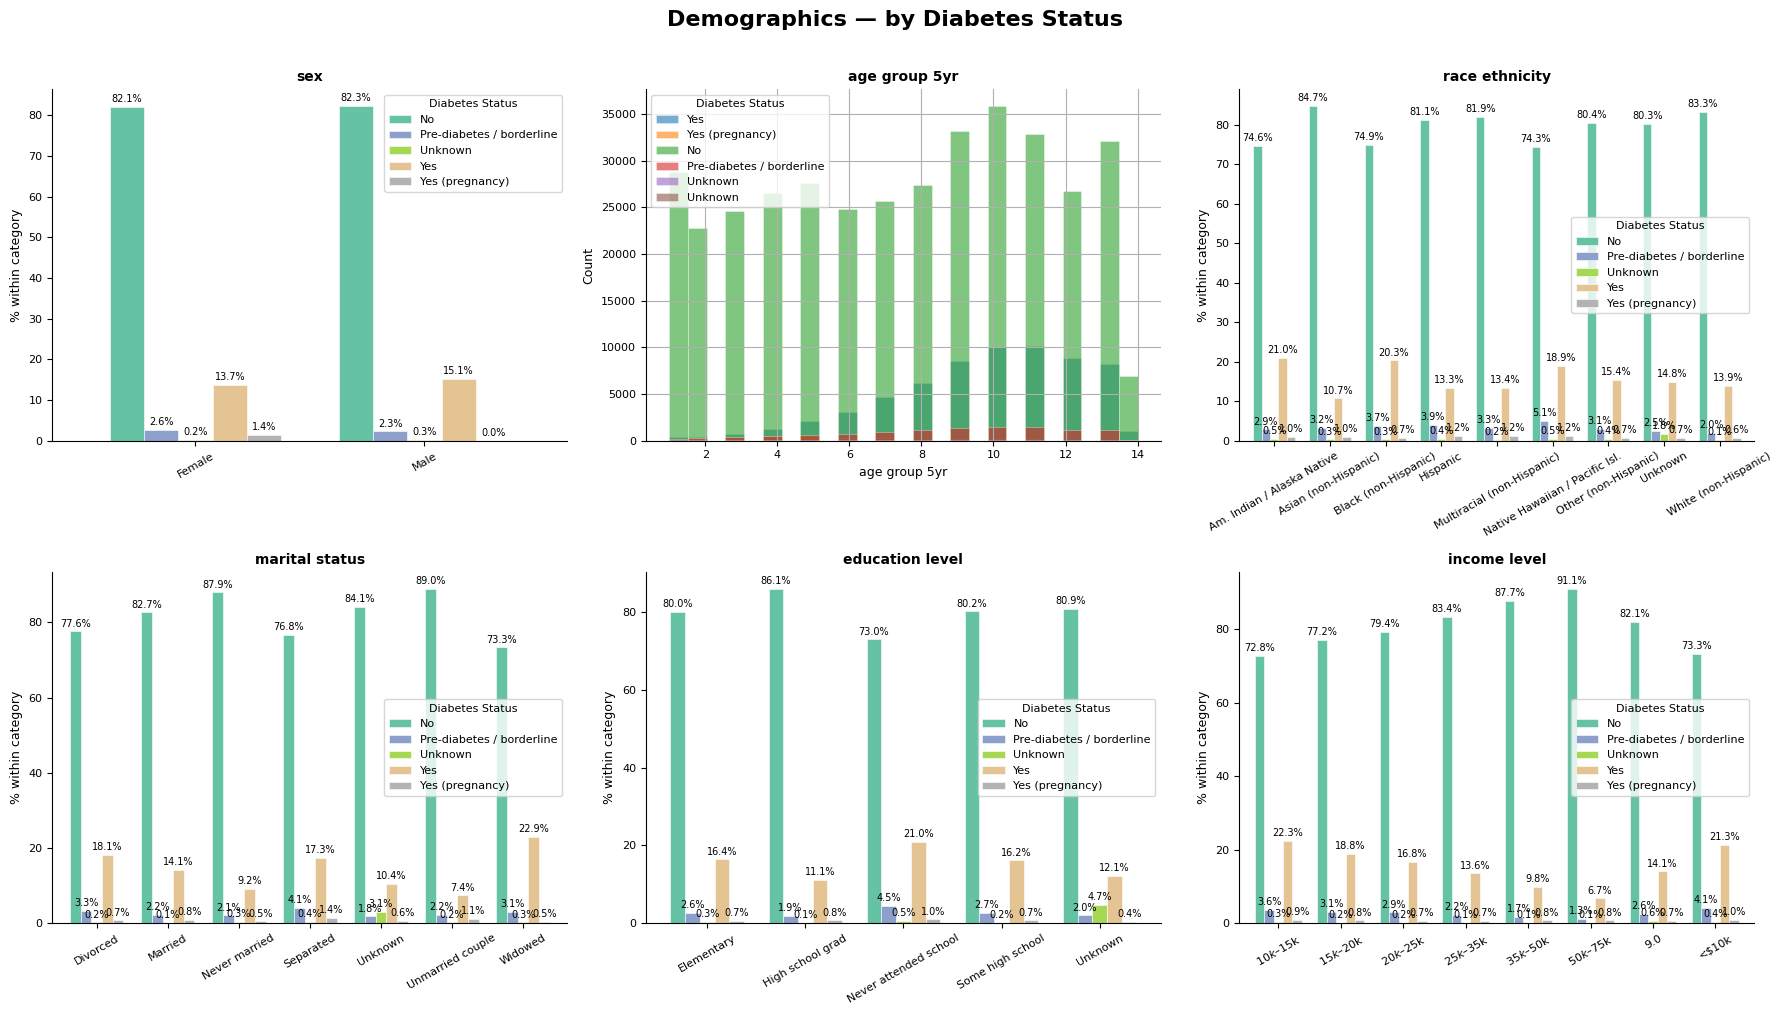

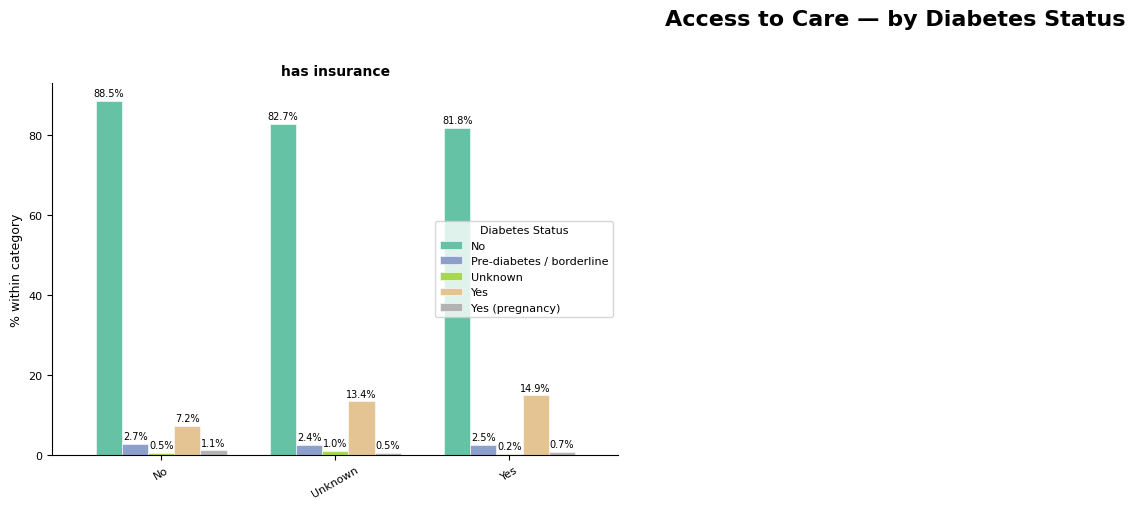

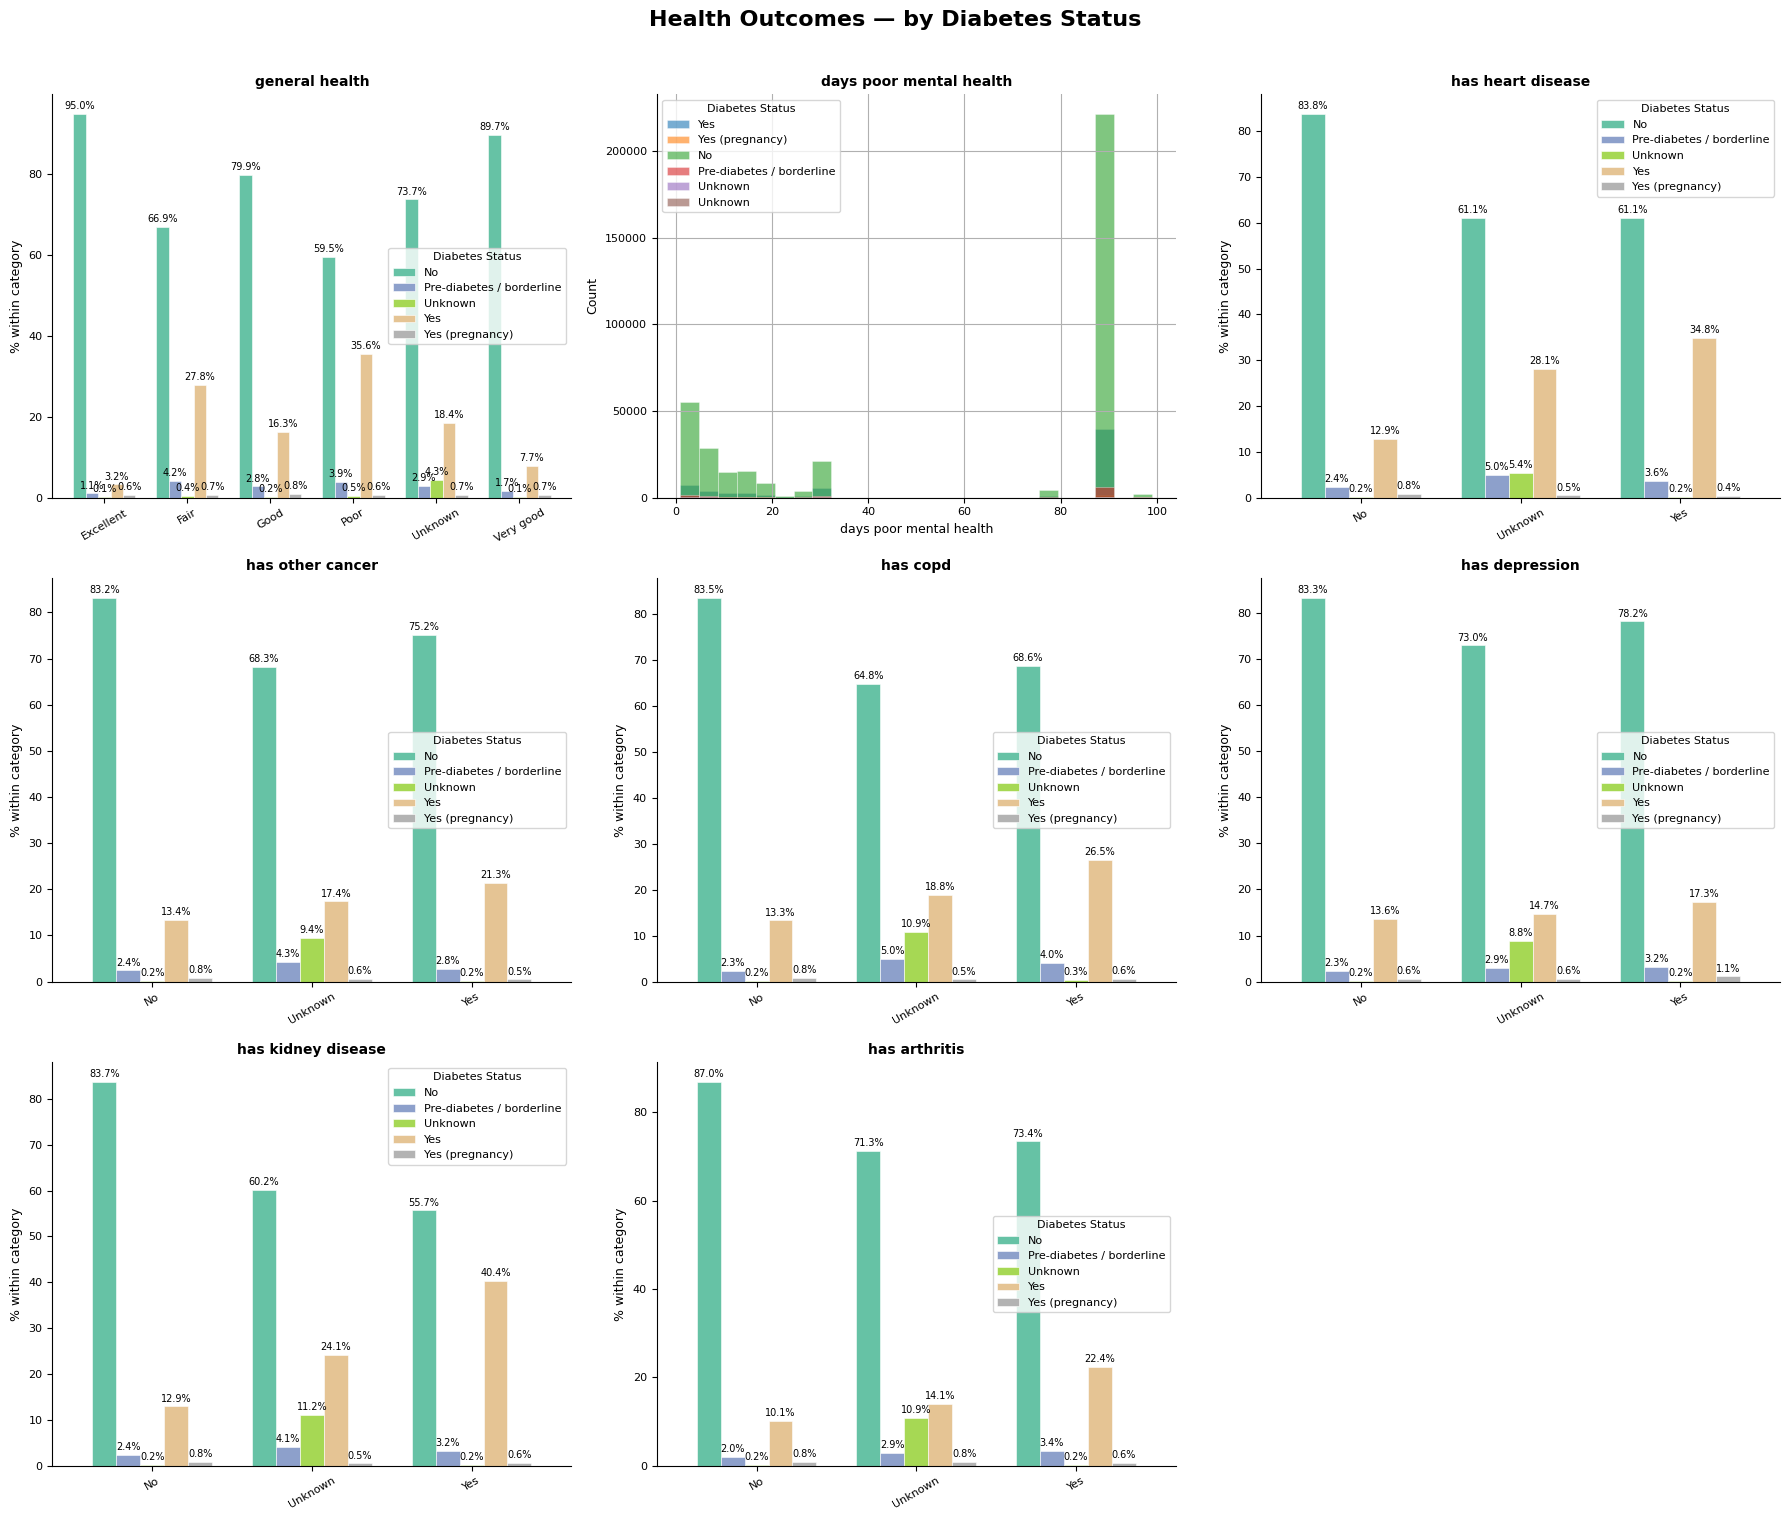

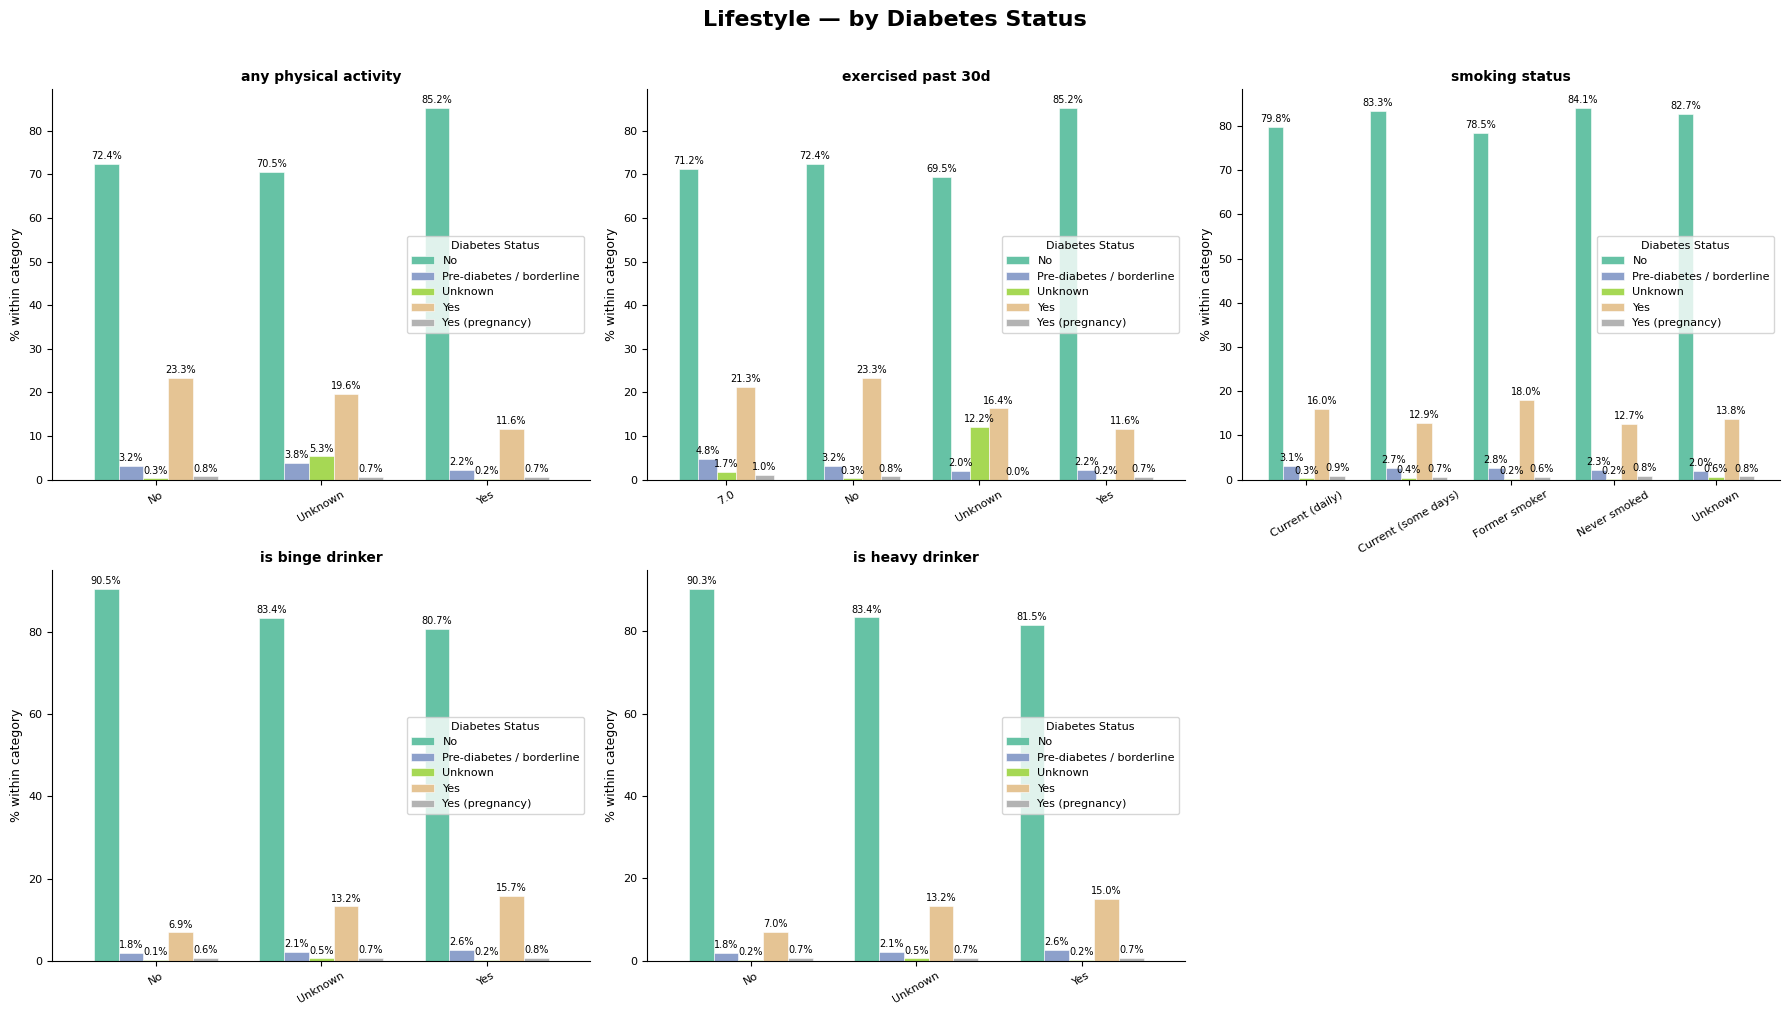

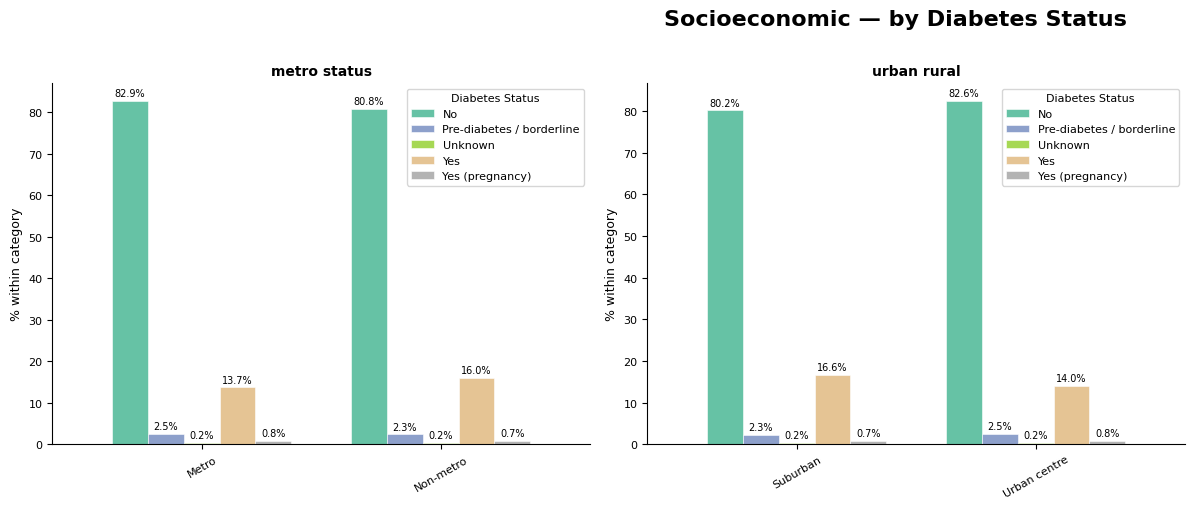

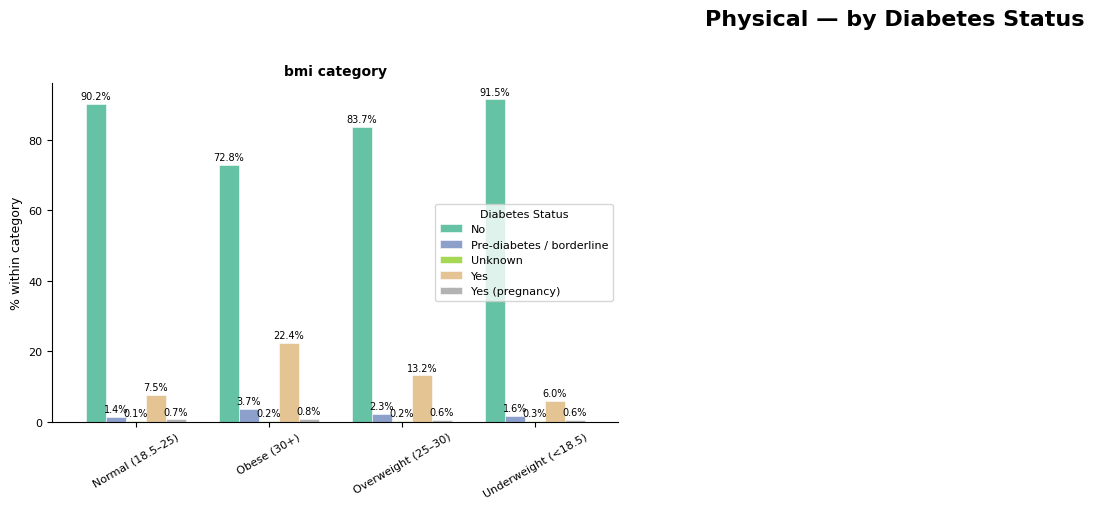

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

feature_groups = {
    "Demographics":    (df_demographics,    ["sex", "age_group_5yr", "race_ethnicity", "marital_status", "education_level", "income_level"]),
    "Access to Care":  (df_access_to_care,  ["has_insurance"]),
    "Health Outcomes": (df_health_outcomes, ["general_health", "days_poor_mental_health", "has_heart_disease", "has_other_cancer", "has_copd", "has_depression", "has_kidney_disease", "has_arthritis"]),
    "Lifestyle":       (df_lifestyle,       ["any_physical_activity", "exercised_past_30d", "smoking_status", "is_binge_drinker", "is_heavy_drinker"]),
    "Socioeconomic":   (df_socioeconomic,   ["metro_status", "urban_rural"]),
    "Physical":        (df_physical,        ["bmi_category"]),
}

target      = df_health_outcomes["has_diabetes"]
target_col  = "has_diabetes"
target_title = "Diabetes Status"

group_colors = {
    "Demographics":    "#378ADD",
    "Access to Care":  "#1D9E75",
    "Health Outcomes": "#D85A30",
    "Lifestyle":       "#BA7517",
    "Socioeconomic":   "#7F77DD",
    "Physical":        "#D4537E",
}

for group_name, (df_grp, cols) in feature_groups.items():
    ncols = 3
    nrows = -(-len(cols) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
    fig.suptitle(f"{group_name} — by {target_title}", fontsize=16, fontweight="bold", y=1.01)
    axes = axes.flatten() if nrows * ncols > 1 else [axes]

    for i, col in enumerate(cols):
        ax = axes[i]
        combined     = pd.concat([df_grp[col], target], axis=1).dropna()
        feature      = combined[col]
        label        = combined[target_col]
        label_mapped = apply_labels(label, target_col)

        if pd.api.types.is_numeric_dtype(feature) and feature.nunique() > 10:
            for val in sorted(label.unique()):
                lbl = LABEL_MAPS.get(target_col, {}).get(val, str(val))
                feature[label == val].hist(bins=25, ax=ax, alpha=0.6,
                                           label=lbl, edgecolor="white", linewidth=0.4)
            ax.set_xlabel(col.replace("_", " "), fontsize=9)
            ax.set_ylabel("Count", fontsize=9)
        else:
            feature_mapped = apply_labels(feature, col)
            tmp = pd.DataFrame({"feature": feature_mapped, "target": label_mapped})
            ct  = pd.crosstab(tmp["feature"], tmp["target"], normalize="index") * 100
            ct.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", linewidth=0.4, width=0.75)
            ax.set_xlabel("")
            ax.set_ylabel("% within category", fontsize=9)
            ax.tick_params(axis="x", rotation=30)
            for container in ax.containers:
                ax.bar_label(container, fmt="%.1f%%", fontsize=7, padding=2)

        ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)
        ax.legend(title=target_title, fontsize=8, title_fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"diabetes_labeled_{group_name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


c) Comparison all categories vs. Heart Disease status 

In [39]:

df_health_outcomes = df_health_outcomes.dropna(subset=['has_heart_disease'])
df_health_outcomes['has_heart_disease'].unique()

array([2., 1., 7., 9.])

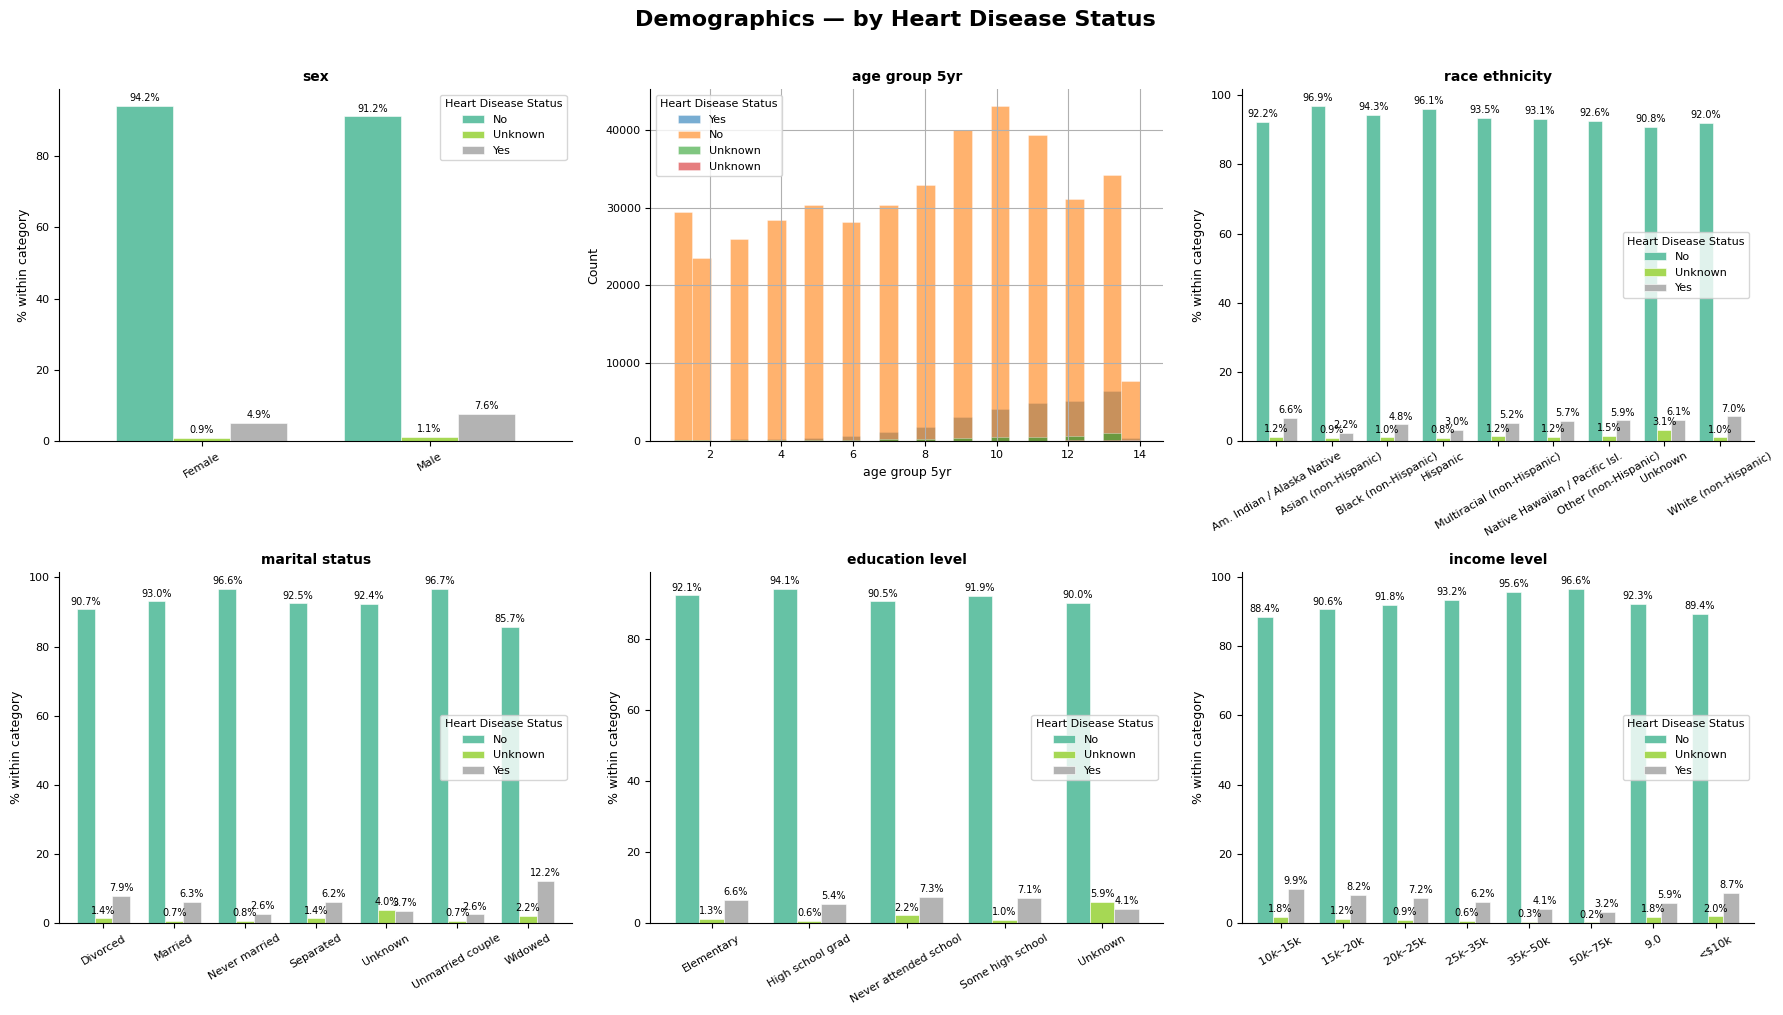

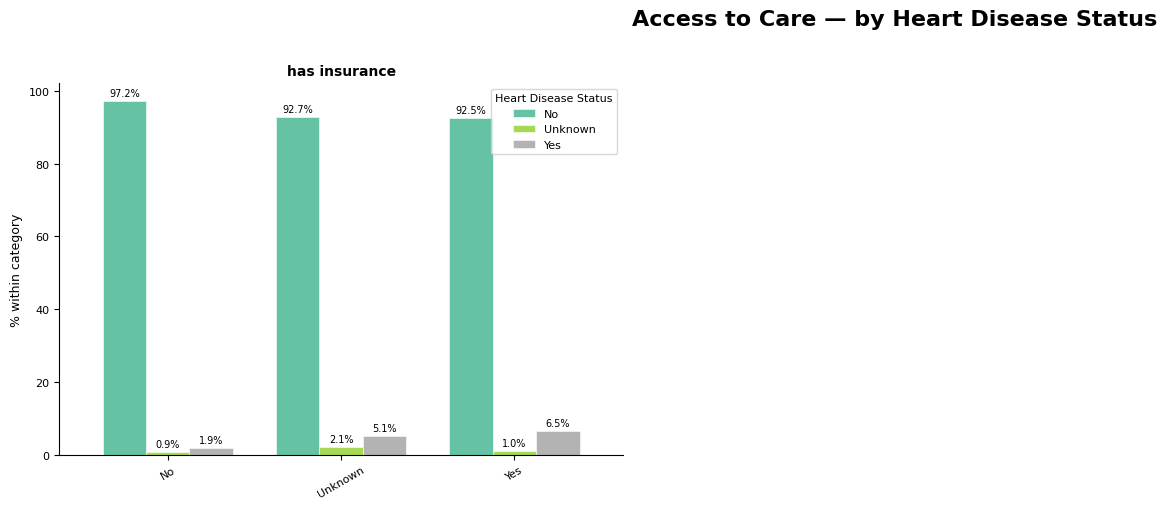

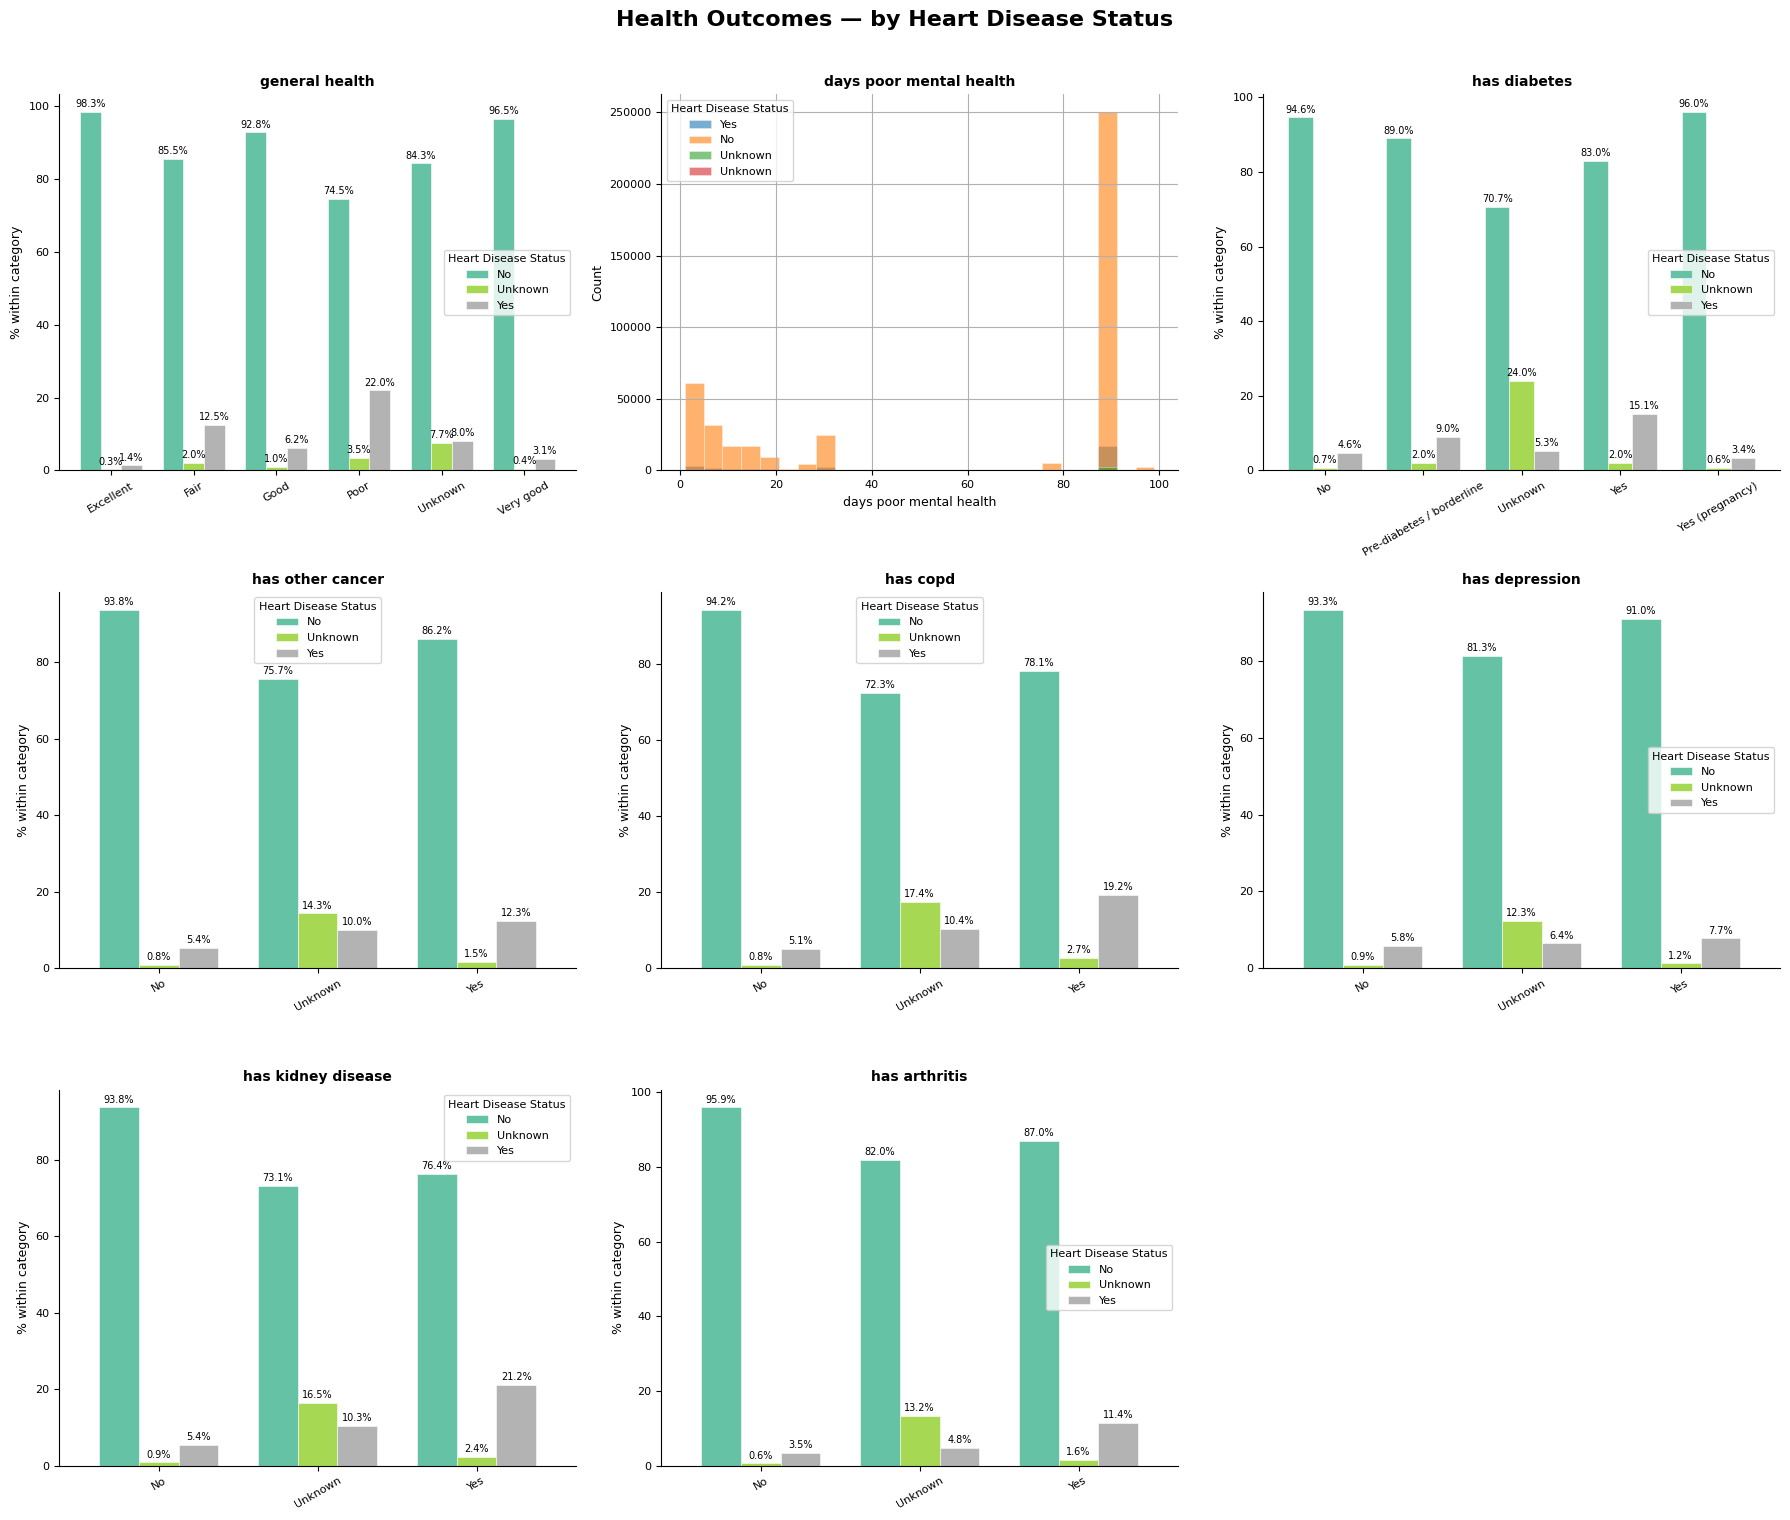

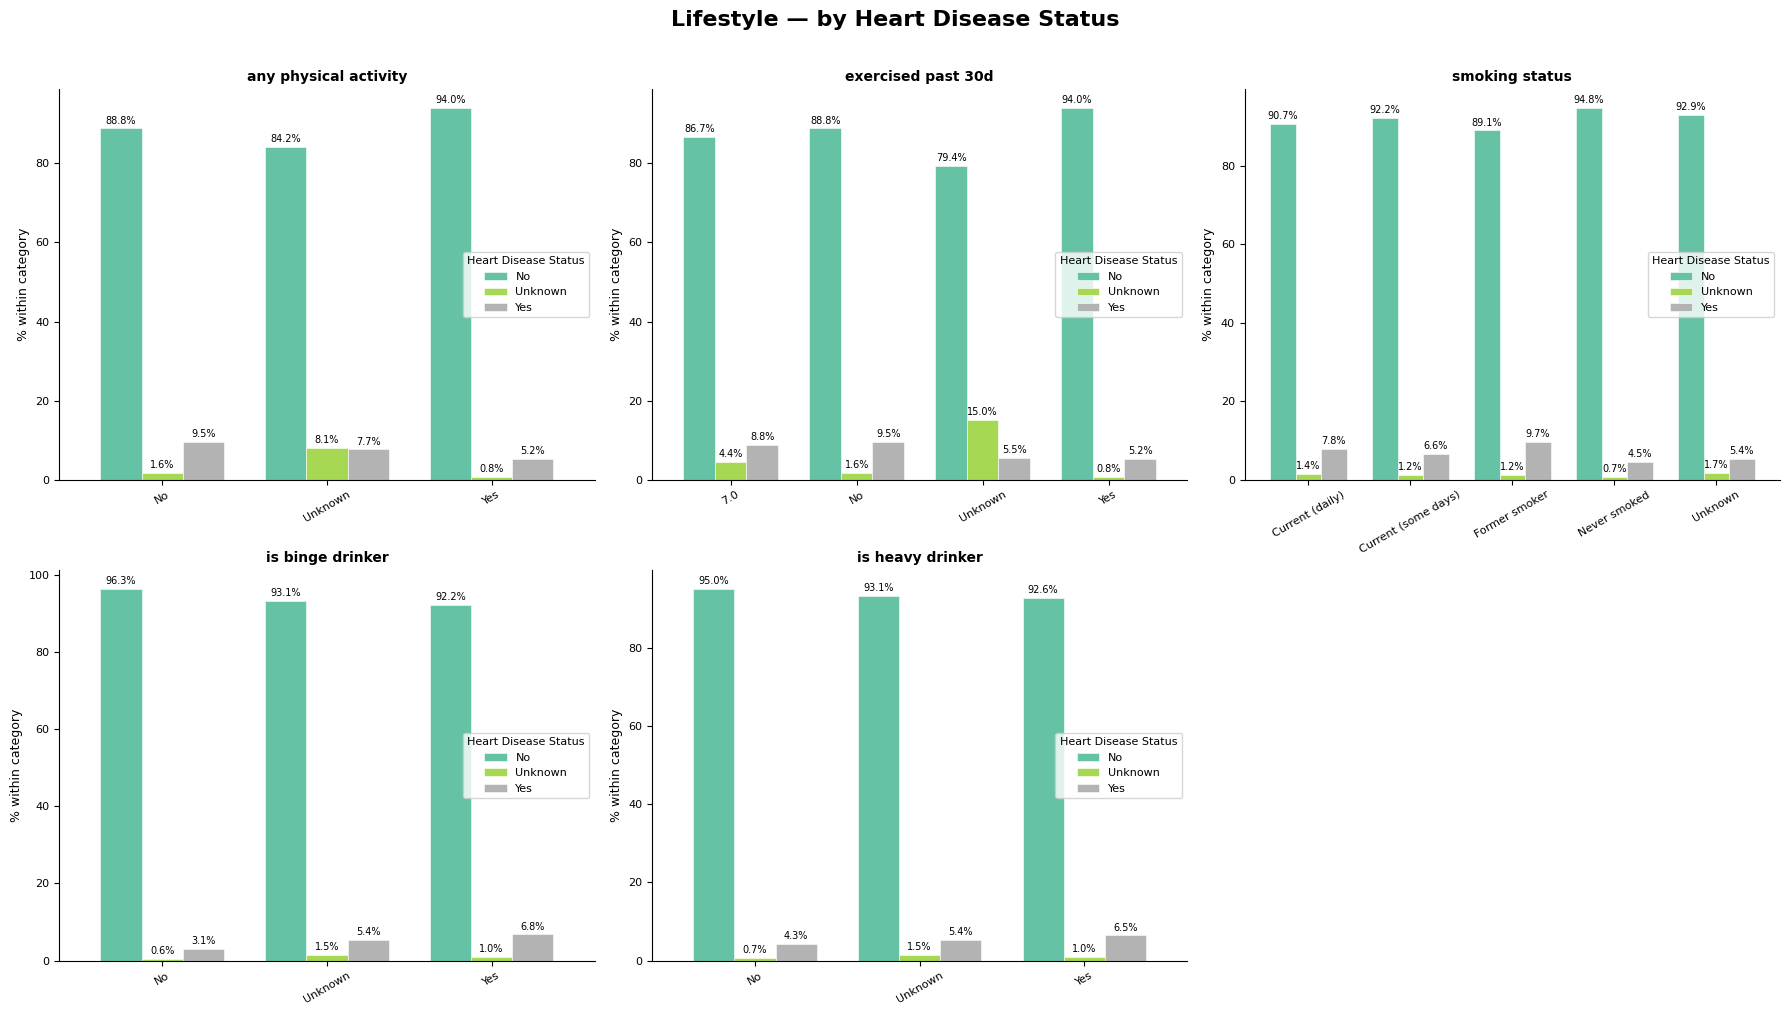

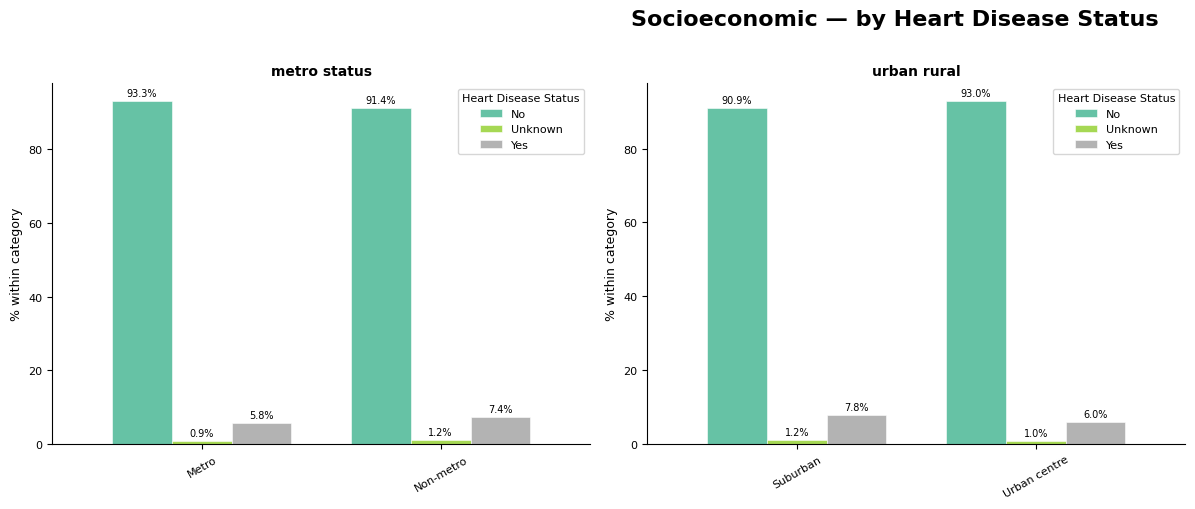

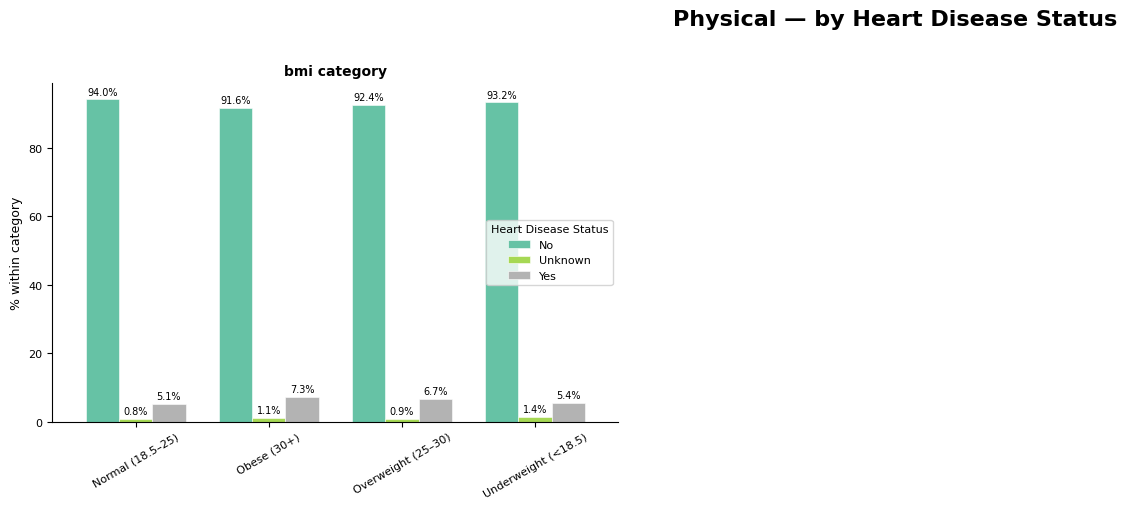

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

feature_groups = {
    "Demographics":    (df_demographics,    ["sex", "age_group_5yr", "race_ethnicity", "marital_status", "education_level", "income_level"]),
    "Access to Care":  (df_access_to_care,  ["has_insurance"]),
    "Health Outcomes": (df_health_outcomes, ["general_health", "days_poor_mental_health", "has_diabetes", "has_other_cancer", "has_copd", "has_depression", "has_kidney_disease", "has_arthritis"]),
    "Lifestyle":       (df_lifestyle,       ["any_physical_activity", "exercised_past_30d", "smoking_status", "is_binge_drinker", "is_heavy_drinker"]),
    "Socioeconomic":   (df_socioeconomic,   ["metro_status", "urban_rural"]),
    "Physical":        (df_physical,        ["bmi_category"]),
}

target       = df_health_outcomes["has_heart_disease"]
target_col   = "has_heart_disease"
target_title = "Heart Disease Status"

group_colors = {
    "Demographics":    "#378ADD",
    "Access to Care":  "#1D9E75",
    "Health Outcomes": "#D85A30",
    "Lifestyle":       "#BA7517",
    "Socioeconomic":   "#7F77DD",
    "Physical":        "#D4537E",
}

for group_name, (df_grp, cols) in feature_groups.items():
    ncols = 3
    nrows = -(-len(cols) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
    fig.suptitle(f"{group_name} — by {target_title}", fontsize=16, fontweight="bold", y=1.01)
    axes = axes.flatten() if nrows * ncols > 1 else [axes]

    for i, col in enumerate(cols):
        ax = axes[i]
        combined     = pd.concat([df_grp[col], target], axis=1).dropna()
        feature      = combined[col]
        label        = combined[target_col]
        label_mapped = apply_labels(label, target_col)

        if pd.api.types.is_numeric_dtype(feature) and feature.nunique() > 10:
            for val in sorted(label.unique()):
                lbl = LABEL_MAPS.get(target_col, {}).get(val, str(val))
                feature[label == val].hist(bins=25, ax=ax, alpha=0.6,
                                           label=lbl, edgecolor="white", linewidth=0.4)
            ax.set_xlabel(col.replace("_", " "), fontsize=9)
            ax.set_ylabel("Count", fontsize=9)
        else:
            feature_mapped = apply_labels(feature, col)
            tmp = pd.DataFrame({"feature": feature_mapped, "target": label_mapped})
            ct  = pd.crosstab(tmp["feature"], tmp["target"], normalize="index") * 100
            ct.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", linewidth=0.4, width=0.75)
            ax.set_xlabel("")
            ax.set_ylabel("% within category", fontsize=9)
            ax.tick_params(axis="x", rotation=30)
            for container in ax.containers:
                ax.bar_label(container, fmt="%.1f%%", fontsize=7, padding=2)

        ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)
        ax.legend(title=target_title, fontsize=8, title_fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"heart_disease_labeled_{group_name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
